# AlphaGenome vs Evo 1: RegulonDB windowing — **positional 8-fold CV**

This is a *variant* of the operon-aware benchmark notebook. **Everything**
— encoders (AG frozen/unfrozen, Evo mean/last), the RegulonDB relational
model, TSS / operon-aware windowing, the bf16 Evo feature fix, the
`fit_head` guards, the Spearman/Pearson metrics, and the operon-position
stratified analysis — **is identical to the reference notebook.**

**The only thing that changes is the cross-validation grouping (§5).**

> Reference notebook: 8-fold CV on the **connected components of a graph
> that unions protein-homology ∪ shared-operon ∪ shared-TU ∪
> overlapping-window edges**, so any two genes that could share predictive
> input are forced into the same fold (leakage-controlled).
>
> **This notebook: a pure positional split.** Genes are sorted by genomic
> coordinate and cut into 8 equal contiguous blocks by rank. Fold *k* is
> the test set, fold *(k+1) mod 8* is validation, the remaining 6 folds
> are train — a clean sliding window where every fold serves as test
> exactly once and as validation exactly once. **No homology, operon, TU,
> or window-overlap grouping is applied at all.**

### This split is deliberately *not* leakage-controlled

Because co-regulated genes are **not** grouped, two genes in the same
operon (which receive an *identical* `operon_aware` window) — or tandem /
divergent genes whose `naive` windows overlap — can land in different
folds. The model can then see the *same input sequence* in train and
test. The reference notebook exists specifically to prevent this; this
notebook intentionally does **not**, so the two can be compared.

The §5b checks below therefore **quantify and report** the cross-fold
TSS-sharing leakage instead of `assert`-ing it to zero. Treat any
correlation uplift here, relative to the reference notebook, as a
plausible **upper bound inflated by leakage**, not a clean estimate.
A contiguous-block split (rather than a random shuffle) keeps the leakage
mostly local to the 7 block boundaries, but does not eliminate it.

Runtime, two-venv `NB_STAGE` switch, and caching are unchanged. The Evo
feature cache from the reference notebook is **reused as-is** — features
do not depend on the CV split, only on the window — so if you already
recomputed the fp32 Evo cache, this notebook does not recompute it.

## 1. Installs

In [1]:
# >>> Environments are provisioned by setup_evo_uv.sh (two UV venvs).
# >>> Do NOT uncomment the pip lines below: re-pulling 'transformers'
# >>> upgrades it past the Evo-1 pin and reintroduces the
# >>> 'module torch has no attribute float8_e8m0fnu' / MHA errors.
#%pip uninstall -y alphagenome_pytorch alphagenome-pytorch
#%pip install -q "alphagenome-pytorch[finetuning] @ git+https://github.com/genomicsxai/alphagenome-pytorch.git"
#%pip install -q biopython tqdm matplotlib scipy huggingface_hub safetensors transformers accelerate einops scikit-learn

In [1]:
import gzip, json, math, copy, gc, re
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from scipy.stats import spearmanr, pearsonr, wilcoxon
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import requests

torch.manual_seed(42); np.random.seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
assert DEVICE == "cuda"
print(f"GPU: {torch.cuda.get_device_name(0)} | VRAM "
      f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

DATA_DIR = Path("data"); DATA_DIR.mkdir(exist_ok=True)
RDB_DIR  = DATA_DIR / "regulondb"; RDB_DIR.mkdir(exist_ok=True)
CACHE_DIR = Path("cache_rdb"); CACHE_DIR.mkdir(exist_ok=True)
CKPT_DIR  = Path("checkpoints_rdb"); CKPT_DIR.mkdir(exist_ok=True)
FIG_DIR   = Path("figures_rdb"); FIG_DIR.mkdir(exist_ok=True)

/grid/koo/home/evyang/Bacteria8/.venv-ag/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA H100 NVL | VRAM 99.9 GB


### Kernel stage switch (added for the two-venv setup)

Evo 1 and AlphaGenome live in **separate** environments, so this notebook is
run in **two passes**, choosing the half to execute with `NB_STAGE`:

* **Pass 1 — Evo.** Start the **"Python (evo)"** kernel (`NB_STAGE=evo`).
  Run cells from the top **through section 7** (the *Evo features* cell).
  Evo features get cached to `cache_rdb/evo_*`. It is normal for a later
  cell to stop with a "cached feature files missing" message — that is the
  AlphaGenome cache, produced in pass 2. Stop after section 7.
* **Pass 2 — AlphaGenome.** Switch to the **"Python (ag)"** kernel
  (`NB_STAGE=ag`) and **Run All**. AG features get cached, then sections
  8–14 (frozen CV, AG-unfrozen, stratified analysis, plots, save) execute
  here because both caches now exist.

Set the kernel's stage by launching Jupyter with `NB_STAGE=evo` or
`NB_STAGE=ag` in the environment, or just edit `STAGE` in the next cell.

In [2]:
import os
# Which half this kernel runs. Override via env: NB_STAGE=evo | NB_STAGE=ag
# (or just hard-set STAGE = "evo" / "ag" here).
STAGE = os.environ.get("NB_STAGE", "evo").strip().lower()
assert STAGE in ("evo", "ag"), f"NB_STAGE must be 'evo' or 'ag', got {STAGE!r}"

# Encoder output widths as CONSTANTS so the cache-only CV stage (sec. 9) runs
# on EITHER kernel even though only one model is importable per venv.
AG_DIM  = 1536      # AlphaGenome encoder width
EVO_DIM = 4096      # Evo-1 / StripedHyena-7B hidden size (re-confirmed from cfg
                    # on the evo kernel below)
STAGE= "ag"
print(f"NB_STAGE = {STAGE!r}  (AG_DIM={AG_DIM}, EVO_DIM={EVO_DIM})")

NB_STAGE = 'ag'  (AG_DIM=1536, EVO_DIM=4096)


## 2. Genome, GFF, expression

In [3]:
REFSEQ_BASE = ("https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/005/845/"
               "GCF_000005845.2_ASM584v2/")
def download(url, dest, timeout=120):
    if dest.exists(): return
    r = requests.get(url, timeout=timeout); r.raise_for_status(); dest.write_bytes(r.content)

fna_gz = DATA_DIR / "ecoli_genome.fna.gz"
gff_gz = DATA_DIR / "ecoli_annotation.gff.gz"
faa_gz = DATA_DIR / "ecoli_proteins.faa.gz"
download(REFSEQ_BASE + "GCF_000005845.2_ASM584v2_genomic.fna.gz", fna_gz)
download(REFSEQ_BASE + "GCF_000005845.2_ASM584v2_genomic.gff.gz", gff_gz)
download(REFSEQ_BASE + "GCF_000005845.2_ASM584v2_protein.faa.gz", faa_gz)

from Bio import SeqIO
with gzip.open(fna_gz, "rt") as fh:
    record = next(SeqIO.parse(fh, "fasta"))
GENOME_SEQ = str(record.seq).upper()
GENOME_LEN = len(GENOME_SEQ)
DOUBLE = GENOME_SEQ + GENOME_SEQ
print(f"E. coli genome: {GENOME_LEN:,} bp")

E. coli genome: 4,641,652 bp


In [4]:
def parse_gff(gff_path):
    rows = []
    with gzip.open(gff_path, "rt") as fh:
        for line in fh:
            if line.startswith("#"): continue
            p = line.rstrip("\n").split("\t")
            if len(p) < 9 or p[2] != "gene": continue
            attrs = dict(kv.split("=", 1) for kv in p[8].split(";") if "=" in kv)
            rows.append({
                "start": int(p[3]) - 1, "end": int(p[4]), "strand": p[6],
                "locus_tag": attrs.get("locus_tag", attrs.get("Name", "")),
                "gene_name": attrs.get("Name", ""),
                "biotype": attrs.get("gene_biotype", "unknown"),
                "pseudo": attrs.get("pseudo", "false") == "true",
            })
    return pd.DataFrame(rows)

genes_df = parse_gff(gff_gz)
genes_df = genes_df[~genes_df.pseudo & (genes_df.end - genes_df.start >= 100)].reset_index(drop=True)
genes_df["length"] = genes_df.end - genes_df.start

PRECISE_URL = "https://raw.githubusercontent.com/SBRG/precise-db/master/data/log_tpm.csv"
precise_path = DATA_DIR / "precise_log_tpm.csv"
if not precise_path.exists():
    r = requests.get(PRECISE_URL, timeout=120); r.raise_for_status()
    precise_path.write_bytes(r.content)
log_tpm = pd.read_csv(precise_path, index_col=0)
expr = log_tpm.median(axis=1).rename("log_tpm").to_frame()
expr.index.name = "locus_tag"
ann = genes_df.merge(expr, left_on="locus_tag", right_index=True, how="inner").reset_index(drop=True)
print(f"Genes with expression: {len(ann)}")

Genes with expression: 3829


## 3. RegulonDB: download and *relationally model* TU / operon / promoter tables

**RegulonDB v12+ rebuilt its site.** Three things broke the old downloader, all
now handled in the cell below:

1. `regulondb.ccg.unam.mx`'s TLS certificate does not verify against the
   default CA store, so every `requests.get()` raised `SSLError` and was
   silently swallowed — *nothing ever downloaded*. The cell now uses
   `verify=RDB_VERIFY_SSL` (default `False`) and silences the warning.
2. The legacy `…/menu/download/datasets/files/<X>.txt` URLs now return an
   HTML landing page, not TSV. The cell validates that a response is a real
   RegulonDB flat file and rejects HTML/SPA/JSON.
3. Failures became `None` and the notebook proceeded to a meaningless
   all-fallback run. A missing *required* table (`tu`, `operon`, `tss`) is
   now a hard `RuntimeError` with explicit recovery steps.

The modern dataset page, **https://regulondb.ccg.unam.mx/datasets**, is a
GraphQL-backed app whose real per-file download URLs are only visible in that
page. Paste those links into the `RDB_URLS` dict at the top of the cell
(right-click the download control → Copy link); they take priority. With
`RDB_URLS` left empty the cell still tries the legacy path and any file you
have hand-placed in `data/regulondb/`.

Everything downstream builds an **explicit relational model** from these
tables (the previous version scraped a couple of guessed columns from the TU
file and ignored the rest):

| Relation | Source table | Built in |
|---|---|---|
| `TU_TO_GENES`           | TU-gene table, or gene list embedded in the TU table | §3a |
| `TU_TO_TSS`             | Promoter / TSS table, joined to TU                   | §3a |
| `OPERON_TO_TUS`         | Operon table (multi-valued TU list), joined to TU    | §3a |
| `GENE_TO_TU` / `…_TUS`  | inverse of `TU_TO_GENES`                             | §3a |
| `GENE_TO_OPERON`        | `GENE_TO_TU` ∘ inverse(`OPERON_TO_TUS`)              | §3a |
| `GENE_TO_SELECTED_TSS`  | primary-promoter pick over the TU's `TU_TO_TSS`      | §3a |

Columns are located by content/ID-pattern detectors (§3 below) and tables are
joined by shared-ID overlap; a manual-override block pins any column the
detectors misread for a given release.

In [5]:
# ============================================================================
# RegulonDB downloader.  Three independently fatal bugs in the prior version,
# all now handled:
#   1. regulondb.ccg.unam.mx's TLS chain does NOT verify with the default CA
#      store -> every requests.get() raised SSLError, which was silently
#      caught -> nothing was ever downloaded.  We set verify=RDB_VERIFY_SSL
#      (default False) and silence the resulting InsecureRequestWarning.
#   2. RegulonDB v12+ was rebuilt; the legacy
#      .../menu/download/datasets/files/<X>.txt URLs now return an HTML
#      terms/landing page, not TSV.  We reject anything that isn't a real
#      RegulonDB flat file.
#   3. Failures became None and the notebook proceeded to a meaningless
#      all-fallback run.  Missing a *required* table is now a hard stop.
#
# Because the new https://regulondb.ccg.unam.mx/datasets page is a GraphQL-
# backed SPA, the *ground-truth* per-table download URLs are only visible in
# that page.  Paste them into RDB_URLS below (right-click the download
# control -> Copy link).  Anything left as None falls back to the legacy
# path attempt, then to a hand-placed file in data/regulondb/.
# ============================================================================

# >>> EDIT ME: paste exact links from https://regulondb.ccg.unam.mx/datasets <<<
RDB_URLS = {
    "tu":      None,   # Transcription Units dataset (TUSet)
    "operon":  None,   # Operons dataset (OperonSet)
    "tss":     None,   # Promoters / TSS dataset (PromoterSet)
    "tu_gene": None,   # optional: TU<->gene / GeneProduct table
}
RDB_VERIFY_SSL = False   # RegulonDB's cert chain fails default verification;
                         # set True only if you have added its CA locally.

# Legacy flat-file path tried automatically when RDB_URLS[...] is None.
RDB_LEGACY_BASES = [
    "https://regulondb.ccg.unam.mx/menu/download/datasets/files/",
    "http://regulondb.ccg.unam.mx/menu/download/datasets/files/",
]
RDB_LEGACY_NAMES = {
    "tu":      ["TUSet.tsv", "TUSet.txt", "TranscriptionUnitSet.txt",
                "TranscriptionUnit.txt"],
    "operon":  ["OperonSet.tsv", "OperonSet.txt", "Operon.txt"],
    "tss":     ["PromoterSet.tsv", "PromoterSet.txt", "Promoter.txt",
                "TSSSet.txt"],
    "tu_gene": ["GeneProductSet.tsv", "GeneProductSet.txt", "TUGene.txt"],
}
RDB_REQUIRED = {"tu", "operon", "tss"}   # tu_gene optional (TUSet embeds genes)

RDB_HEADERS = {
    "User-Agent": "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/124.0 Safari/537.36",
    "Accept": "text/plain,application/octet-stream,application/json,*/*",
}
try:
    import urllib3
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
except Exception:
    pass

def _looks_like_rdb_flatfile(content: bytes) -> bool:
    """Real RegulonDB TSV: '#' header lines or many tab-delimited rows, and
    not an HTML document and not a GraphQL/JSON error blob."""
    head = content[:4096].lstrip().lower()
    if head[:14] == b"<!doctype html" or head[:5] == b"<html" \
       or b"<head>" in head or b"<body" in head:
        return False
    text = content[:8192].decode("latin-1", "ignore")
    lines = text.splitlines()
    has_comment  = any(ln.startswith("#") for ln in lines[:50])
    has_tsv_rows = sum(("\t" in ln) for ln in lines[:200]) >= 3
    return has_comment or has_tsv_rows

def _fetch(url, sess):
    try:
        r = sess.get(url, timeout=180, allow_redirects=True,
                      verify=RDB_VERIFY_SSL)
    except Exception as e:
        return None, f"{type(e).__name__}: {e}"
    if r.status_code != 200:
        return None, f"HTTP {r.status_code}"
    if len(r.content) < 200 or not _looks_like_rdb_flatfile(r.content):
        return None, (f"{len(r.content)} B but not a RegulonDB flat file "
                      f"(HTML landing page / SPA / error?)")
    return r.content, None

def resolve_rdb(logical):
    """1) hand-placed file  2) explicit RDB_URLS  3) legacy path attempt."""
    # 1) any previously written / manually placed valid file
    for nm in RDB_LEGACY_NAMES[logical]:
        dest = RDB_DIR / nm
        if dest.exists() and dest.stat().st_size > 0 \
           and _looks_like_rdb_flatfile(dest.read_bytes()):
            print(f"  [{logical}] using local {nm} "
                  f"({dest.stat().st_size//1024} KB)")
            return dest
    sess = requests.Session(); sess.headers.update(RDB_HEADERS)
    # 2) explicit user-supplied URL (ground truth from /datasets page)
    if RDB_URLS.get(logical):
        url = RDB_URLS[logical]
        content, err = _fetch(url, sess)
        if content is not None:
            dest = RDB_DIR / f"{logical}.txt"
            dest.write_bytes(content)
            print(f"  [{logical}] downloaded from RDB_URLS "
                  f"({len(content)//1024} KB)")
            return dest
        print(f"  [{logical}] RDB_URLS link failed: {err}")
    # 3) legacy flat-file path
    for nm in RDB_LEGACY_NAMES[logical]:
        for base in RDB_LEGACY_BASES:
            content, err = _fetch(base + nm, sess)
            if content is not None:
                dest = RDB_DIR / nm
                dest.write_bytes(content)
                print(f"  [{logical}] downloaded {nm} "
                      f"({len(content)//1024} KB) from legacy path")
                return dest
            print(f"  [{logical}] {base}{nm}: {err}")
    return None

rdb_files = {k: resolve_rdb(k) for k in RDB_LEGACY_NAMES}
print("\nRegulonDB files resolved:",
      {k: (v.name if v else None) for k, v in rdb_files.items()})

missing = sorted(k for k in RDB_REQUIRED if rdb_files.get(k) is None)
if missing:
    raise RuntimeError(
        f"RegulonDB download FAILED for required table(s): {missing}. "
        "Hard stop (an all-fallback run would be meaningless). Do ONE of:\n"
        "  (a) Open https://regulondb.ccg.unam.mx/datasets , right-click the "
        "download link for each missing table, paste the URLs into RDB_URLS "
        "at the top of this cell, and re-run.\n"
        f"  (b) Download the files in a browser and drop them in {RDB_DIR}/ "
        "(any of these names works: "
        + "; ".join(f"{k}:{RDB_LEGACY_NAMES[k]}" for k in missing) + ").\n"
        "  (c) If TLS is the problem on your network, RDB_VERIFY_SSL is "
        f"already {RDB_VERIFY_SSL}; if it is True, set it False and re-run.\n"
        "  (d) If this host has no outbound access to regulondb.ccg.unam.mx, "
        "stage the files from a machine that does.")
if rdb_files.get("tu_gene") is None:
    print("  note: no TU-gene table — TU<->gene links will come from the "
          "gene list embedded in the TU table (handled in §3a).")


  [tu] using local TUSet.tsv (407 KB)
  [operon] using local OperonSet.tsv (225 KB)
  [tss] using local PromoterSet.tsv (920 KB)
  [tu_gene] https://regulondb.ccg.unam.mx/menu/download/datasets/files/GeneProductSet.tsv: 1653 B but not a RegulonDB flat file (HTML landing page / SPA / error?)
  [tu_gene] http://regulondb.ccg.unam.mx/menu/download/datasets/files/GeneProductSet.tsv: ConnectionError: HTTPConnectionPool(host='regulondb.ccg.unam.mx', port=80): Max retries exceeded with url: /menu/download/datasets/files/GeneProductSet.tsv (Caused by NewConnectionError("HTTPConnection(host='regulondb.ccg.unam.mx', port=80): Failed to establish a new connection: [Errno 111] Connection refused"))
  [tu_gene] https://regulondb.ccg.unam.mx/menu/download/datasets/files/GeneProductSet.txt: 1653 B but not a RegulonDB flat file (HTML landing page / SPA / error?)
  [tu_gene] http://regulondb.ccg.unam.mx/menu/download/datasets/files/GeneProductSet.txt: ConnectionError: HTTPConnectionPool(host='regulondb

In [6]:
def read_rdb_table(path):
    """Parse a RegulonDB flat file.

    RegulonDB v12+ files have a block of '#'-prefixed license/citation/column
    comment lines, then ONE header line whose tab tokens look like
    'N)columnName' (e.g. '1)tuId\t2)tuName\t3)operonId...'), then TSV data.
    We use that header for real column names (stripping the 'N)' prefix);
    fields are whitespace-trimmed (RegulonDB pads with trailing spaces/tabs).
    If no such header exists (older releases), fall back to positional
    col0..colN so the §3 content-detectors still work."""
    if path is None:
        return None
    hdr_rx = re.compile(r"^\s*\d+\)\s*\S")
    tok_rx = re.compile(r"^\s*\d+\)\s*(.*)$")
    header, data, raw_header = None, [], ""
    with open(path, "r", encoding="latin-1") as fh:
        for line in fh:
            line = line.rstrip("\r\n")
            if not line.strip():
                continue
            if line.lstrip().startswith("#"):          # license / ## Columns
                continue
            if header is None and hdr_rx.match(line):   # the real header row
                raw_header = line
                cols = []
                for tok in line.split("\t"):
                    m = tok_rx.match(tok)
                    cols.append((m.group(1) if m else tok).strip())
                seen, uniq = {}, []                     # de-dup safety
                for c in cols:
                    if c in seen:
                        seen[c] += 1; uniq.append(f"{c}_{seen[c]}")
                    else:
                        seen[c] = 0; uniq.append(c)
                header = uniq
                continue
            data.append(line.split("\t"))
    if not data:
        return pd.DataFrame()
    if header is None:                                  # positional fallback
        header = [f"col{i}" for i in range(max(len(r) for r in data))]
    ncol = len(header)
    norm = []
    for r in data:
        r = [c.strip() for c in r]
        r = (r + [""] * (ncol - len(r))) if len(r) < ncol else r[:ncol]
        norm.append(r)
    df = pd.DataFrame(norm, columns=header)
    df.attrs["header_hint"] = raw_header
    return df

tu_raw     = read_rdb_table(rdb_files["tu"])
operon_raw = read_rdb_table(rdb_files["operon"])
tss_raw    = read_rdb_table(rdb_files["tss"])
tugene_raw = read_rdb_table(rdb_files["tu_gene"])   # None for v12+ (TUSet has genes)

for name, df in [("TU", tu_raw), ("operon", operon_raw),
                 ("TSS/promoter", tss_raw), ("TU-gene", tugene_raw)]:
    if df is None:
        print(f"{name:13s}: MISSING (ok if TU-gene: TUSet embeds the gene list)")
        continue
    print(f"{name:13s}: shape {df.shape} | columns: {list(df.columns)[:12]}")


TU           : shape (3767, 11) | columns: ['tuId', 'tuName', 'operonId', 'operonName', 'tuGenes', 'pmName', 'terminatorIds', 'tuEvidence', 'addEvidence', 'confidenceLevel', 'pmids']
operon       : shape (2605, 9) | columns: ['operonId', 'operonName', 'firstGeneLeftPos', 'lastGeneRightPos', 'strand', 'numberOfGenes', 'operonGenes', 'operonEvidence', 'confidenceLevel']
TSS/promoter : shape (4057, 16) | columns: ['pmId', 'pmName', 'strand', 'posTSS', 'sigmaFactor', 'pmSequence', 'firstGeneName', 'distToFirstGene', 'boxMinus10pos', 'boxMinus10seq', 'boxMinus35pos', 'boxMinus35seq']
TU-gene      : MISSING (ok if TU-gene: TUSet embeds the gene list)


### 3a. Parse the three RegulonDB v12+ files → six explicit relations

`read_rdb_table` now reads RegulonDB's `N)columnName` header line, so the
tables arrive with their real names (`tuId`, `operonId`, `tuGenes`, `pmName`,
`pmId`, `posTSS`, `confidenceLevel`, …). The builder detects this canonical
schema and parses it **deterministically** (no content-detector guessing):

- **TU→genes** from `TUSet.tuGenes` (semicolon list) — no separate TU-gene
  file is needed in v12+.
- **TU→operon** from `TUSet.operonId` (a real foreign key).
- **TU→TSS** by joining `TUSet.pmName` to `PromoterSet.pmName` — the
  promoter↔TU link in v12+ is the promoter *name*, not a shared ID, so the
  generic overlap-join cannot find it; the canonical path does. Each promoter
  row is fanned out to every TU it transcribes.
- **operon→TUs** by inverting `TUSet.operonId` (`OperonSet` has no TU-id
  column), with `OperonSet.strand` merged in.
- primary promoter per TU chosen by `confidenceLevel`
  (Confirmed > Strong > Weak) then upstream proximity to the operon's first
  gene.

If the canonical columns are absent (older/other release) the builder falls
back to the content/ID-pattern detectors. Either way the six relations and a
coverage report are produced; an expanded MANUAL OVERRIDE block still lets you
pin columns for the fallback path. Genes whose TU/operon has no curated
promoter get no selected TSS and are tagged `annotation_source == "fallback"`
(this is real RegulonDB incompleteness — see the §12 annotated-only check).

In [7]:
# ---- Content + ID-pattern detectors for schema-tolerant RegulonDB parsing ----
KNOWN_TAGS  = set(ann.locus_tag)                 # b#### Blattner numbers
KNOWN_NAMES = set(ann.gene_name.str.lower())
name_to_tag = dict(zip(ann.gene_name.str.lower(), ann.locus_tag))

def to_locus(tok):
    """Map a RegulonDB gene token (b-number / gene name) to our locus_tag, or None."""
    t = str(tok).strip()
    if t in KNOWN_TAGS:            return t
    if t.lower() in name_to_tag:   return name_to_tag[t.lower()]
    return None

# RegulonDB object-ID regexes (cover 10.x ECK-style and 11.x RDBECOLI-style).
RX_TU_ID     = re.compile(r"^(RDBECOLITU\w+|ECK125\w+|ECK120\w+|TU\d+)$", re.I)
RX_OPERON_ID = re.compile(r"^(RDBECOLIOP\w+|ECK125\w+|ECK120\w+|O\w*\d{2,})$", re.I)
RX_PROM_ID   = re.compile(r"^(RDBECOLIPD\w+|RDBECOLIPM\w+|ECK125\w+|ECK120\w+|P[MD]\d+)$", re.I)
RX_GENE_ID   = re.compile(r"^(RDBECOLIG\w+|ECK125\w+|ECK120\w+)$", re.I)
RX_LOCUS     = re.compile(r"^b\d{4}$")

SPLIT_RX = re.compile(r"[;,\|\s]+")
def split_tokens(cell):
    return [g for g in SPLIT_RX.split(str(cell).strip()) if g and g.lower() != "nan"]

def _frac_match(series, rx):
    s = series.astype(str).str.strip()
    if len(s) == 0: return 0.0
    return float(s.str.match(rx).mean())

def f_locus(s):   return _frac_match(s, RX_LOCUS)
def f_tu_id(s):   return _frac_match(s, RX_TU_ID)
def f_op_id(s):   return _frac_match(s, RX_OPERON_ID)
def f_prom_id(s): return _frac_match(s, RX_PROM_ID)
def f_gene_id(s): return _frac_match(s, RX_GENE_ID)
def f_name(s):    return float(s.astype(str).str.lower().str.strip().isin(KNOWN_NAMES).mean())
def f_pos(s):
    v = pd.to_numeric(s, errors="coerce")
    return float(v.between(1, GENOME_LEN).mean())
def f_strand(s):
    return float(s.astype(str).str.lower().str.strip()
                 .isin(["forward", "reverse", "+", "-", "f", "r"]).mean())
def f_genelist(s):
    """Column whose *tokens* are mostly resolvable genes (embedded gene lists)."""
    def ok(cell):
        toks = split_tokens(cell)
        if not toks: return 0.0
        return np.mean([to_locus(t) is not None for t in toks])
    return float(np.mean([ok(x) for x in s.astype(str)]))

def best_col(df, detector, min_score=0.30):
    """(colname, score) of the column maximizing `detector`; None if below threshold."""
    if df is None or len(df) == 0: return (None, 0.0)
    best, bs = None, 0.0
    for c in df.columns:
        try:    sc = detector(df[c])
        except Exception: sc = 0.0
        if sc > bs: best, bs = c, sc
    return (best if bs >= min_score else None, round(bs, 3))

def join_col(df_a, col_a, df_b, min_overlap=0.10, multivalued=False):
    """Find the column in df_b that is the foreign key to df_a[col_a], by value-set
    overlap (Jaccard-ish, normalized by the smaller set). If multivalued, df_b cells
    may contain delimited lists of ids."""
    if df_a is None or df_b is None or col_a is None: return (None, 0.0)
    ref = set(df_a[col_a].astype(str).str.strip()) - {"", "nan"}
    if not ref: return (None, 0.0)
    best, bs = None, 0.0
    for c in df_b.columns:
        if multivalued:
            vals = set()
            for cell in df_b[c].astype(str):
                vals.update(split_tokens(cell))
        else:
            vals = set(df_b[c].astype(str).str.strip())
        vals -= {"", "nan"}
        if not vals: continue
        ov = len(ref & vals) / max(1, min(len(ref), len(vals)))
        if ov > bs: best, bs = c, ov
    return (best if bs >= min_overlap else None, round(bs, 3))

# Quick visibility into what each raw table looks like to the detectors.
for nm, df in [("TU", tu_raw), ("operon", operon_raw),
               ("promoter/TSS", tss_raw), ("TU-gene", tugene_raw)]:
    if df is None or len(df) == 0:
        print(f"{nm:14s}: MISSING / empty"); continue
    print(f"{nm:14s}: shape {df.shape} | "
          f"locus={best_col(df, f_locus)} name={best_col(df, f_name)} "
          f"tu_id={best_col(df, f_tu_id)} op_id={best_col(df, f_op_id)} "
          f"prom_id={best_col(df, f_prom_id)} pos={best_col(df, f_pos)} "
          f"strand={best_col(df, f_strand)} genelist={best_col(df, f_genelist)}")


TU            : shape (3767, 11) | locus=(None, 0.0) name=('tuName', 0.533) tu_id=('tuId', 1.0) op_id=('operonId', 1.0) prom_id=(None, 0.0) pos=(None, 0.042) strand=(None, 0.0) genelist=('tuGenes', 0.864)
operon        : shape (2605, 9) | locus=(None, 0.0) name=('operonGenes', 0.563) tu_id=(None, 0.0) op_id=('operonId', 1.0) prom_id=(None, 0.0) pos=('firstGeneLeftPos', 1.0) strand=('strand', 1.0) genelist=('operonGenes', 0.841)
promoter/TSS  : shape (4057, 16) | locus=(None, 0.0) name=('firstGeneName', 0.483) tu_id=(None, 0.0) op_id=(None, 0.0) prom_id=('pmId', 1.0) pos=('posTSS', 0.977) strand=('strand', 1.0) genelist=('firstGeneName', 0.483)
TU-gene       : MISSING / empty


In [8]:
# ============================================================================
# MANUAL OVERRIDE BLOCK — only edit if a coverage number below is implausibly
# low. Set "<table>_<role>_COL" to a raw column name like "col3" to pin it;
# leave None to use the content/ID detectors above.
TU_ID_COL       = None   # TU identifier in the TU table
TU_OPERON_COL   = None   # operon id/name in the TU table (link TU -> operon)
TU_STRAND_COL   = None
TU_GENELIST_COL = None   # embedded gene list in the TU table (fallback membership)

TG_TU_COL       = None   # TU id in the TU-gene table
TG_GENE_COL     = None   # gene (locus/name) in the TU-gene table

PR_ID_COL       = None   # promoter id in the promoter/TSS table
PR_POS_COL      = None   # TSS genome position
PR_STRAND_COL   = None
PR_TU_COL       = None   # the column that links a promoter to its TU (or operon)
PR_EVID_COL     = None   # optional evidence/confidence column

OP_ID_COL       = None   # operon identifier
OP_TULIST_COL   = None   # delimited list of member TU ids
OP_STRAND_COL   = None
# ============================================================================

def _norm_strand(x):
    x = str(x).lower().strip()
    if x in ("forward", "+", "f"): return "+"
    if x in ("reverse", "-", "r"): return "-"
    return None

def pick(df, override, detector, min_score=0.30):
    if df is None or len(df) == 0: return None
    if override is not None:       return override
    return best_col(df, detector, min_score)[0]

from collections import defaultdict

# Deterministic path for RegulonDB v12+ ("*Set" files: TUSet/PromoterSet/
# OperonSet).  read_rdb_table now yields the real column names, so we parse
# by schema instead of guessing.  Critically, the promoter<->TU link is the
# promoter NAME (TUSet.pmName == PromoterSet.pmName) — not any shared ID — so
# the generic content-detector join cannot find it; this branch does.
def _canon(df, cols):
    return df is not None and len(df) and set(cols).issubset(set(df.columns))

CANON = (_canon(tu_raw,  ["tuId", "operonId", "tuGenes"]) and
         _canon(tss_raw, ["pmId", "pmName", "posTSS", "strand"]))

if CANON:
    print("RegulonDB v12+ canonical schema detected — deterministic parse "
          "(no content-detector guessing).")

    def _genes(cell):
        return [t for t in re.split(r"[;,]\s*", str(cell).strip())
                if t and t.lower() != "nan"]

    # --- tu_df : tu_id, operon FK (real), promoter name, embedded gene list
    tu_df = pd.DataFrame({
        "tu_id":      tu_raw["tuId"].astype(str).str.strip(),
        "operon_key": tu_raw["operonId"].astype(str).str.strip(),
        "strand":     None,                       # TUSet has no strand col;
                                                  # strand flows from promoter
                                                  # / gene in §3a
        "genelist":   tu_raw["tuGenes"].astype(str),
        "pm_name":    (tu_raw["pmName"].astype(str).str.strip()
                       if "pmName" in tu_raw.columns else ""),
    })
    tu_df = tu_df[tu_df.tu_id.ne("") & tu_df.tu_id.ne("nan")] \
              .drop_duplicates("tu_id")

    # --- tugene_df : TU -> gene, straight from TUSet.tuGenes (v12+ has no
    #     separate TU-gene file)
    recs = []
    for _, r in tu_raw.iterrows():
        tu = str(r["tuId"]).strip()
        for g in _genes(r["tuGenes"]):
            lt = to_locus(g)
            if tu and lt:
                recs.append({"tu_id": tu, "locus_tag": lt})
    tugene_df = pd.DataFrame(recs, columns=["tu_id", "locus_tag"]) \
                  .drop_duplicates()

    # --- promoter name -> the TU(s) it transcribes (a promoter may serve
    #     several alternative TUs)
    pm2tu = defaultdict(list)
    if "pmName" in tu_raw.columns:
        for _, r in tu_raw.iterrows():
            pm = str(r["pmName"]).strip(); tu = str(r["tuId"]).strip()
            if pm and pm.lower() != "nan" and tu:
                pm2tu[pm].append(tu)

    # --- promoter_df : ONE ROW PER (promoter, TU it serves) so §3a's
    #     per-row append fans each TSS to every TU correctly.
    #     evidence string is crafted so §3a's ev_score keywords fire:
    #     confidenceLevel C/S/W -> confirmed/strong/weak, plus pmEvidence.
    def _evid(r):
        cl = str(r.get("confidenceLevel", "")).strip()
        word = {"C": "confirmed", "S": "strong", "W": "weak"}.get(
            cl[:1].upper(), cl.lower())
        return f"{word} {str(r.get('pmEvidence', '')).strip()}".strip()

    prows = []
    for _, r in tss_raw.iterrows():
        pos = pd.to_numeric(r.get("posTSS"), errors="coerce")
        if not (pos == pos and 1 <= pos <= GENOME_LEN):   # NaN-safe
            continue
        base = {"prom_id": str(r.get("pmId", "")).strip(),
                "tss_pos": int(pos),
                "strand":  _norm_strand(r.get("strand")),
                "evidence": _evid(r)}
        pm = str(r.get("pmName", "")).strip()
        tus = pm2tu.get(pm, [])
        if tus:
            for tu in tus:
                prows.append({**base, "tu_key": tu})
        else:
            prows.append({**base, "tu_key": ""})       # keep, just unlinked
    promoter_df = pd.DataFrame(
        prows, columns=["prom_id", "tss_pos", "strand", "evidence", "tu_key"])

    # --- operon_df : OperonSet has NO TU-id column, so the operon->TU
    #     mapping is the inverse of TUSet.operonId; merge OperonSet strand.
    op_tus = defaultdict(list)
    for _, r in tu_df.iterrows():
        ok = str(r.operon_key).strip()
        if ok and ok.lower() != "nan":
            op_tus[ok].append(r.tu_id)
    op_strand = {}
    if operon_raw is not None and "operonId" in operon_raw.columns:
        sc = "strand" if "strand" in operon_raw.columns else None
        for _, r in operon_raw.iterrows():
            oi = str(r["operonId"]).strip()
            if oi:
                op_strand[oi] = _norm_strand(r.get(sc)) if sc else None
    operon_df = pd.DataFrame(
        [{"operon_id": op, "tu_list": tus, "strand": op_strand.get(op)}
         for op, tus in op_tus.items()],
        columns=["operon_id", "tu_list", "strand"])

    print(f"  tu_df={len(tu_df)}  tugene_df={len(tugene_df)} TU-gene links  "
          f"promoter_df={len(promoter_df)} rows "
          f"(TU-linked {int((promoter_df.tu_key != '').sum())})  "
          f"operon_df={len(operon_df)} operons")

else:
    print("Canonical RegulonDB columns absent — using content-detector "
          "fallback (older/unknown release).")

    # ---- promoter / TSS table -> promoter_df ----------------------------------
    promoter_df = pd.DataFrame(columns=["prom_id", "tss_pos", "strand", "evidence", "tu_key"])
    if tss_raw is not None and len(tss_raw):
        pid = pick(tss_raw, PR_ID_COL,     f_prom_id, 0.20)
        ppo = pick(tss_raw, PR_POS_COL,    f_pos,     0.30)
        pst = pick(tss_raw, PR_STRAND_COL, f_strand,  0.30)
        # evidence: a column with words like strong/weak/confirmed/HT, else a numeric score
        pev = PR_EVID_COL
        if pev is None:
            for c in tss_raw.columns:
                low = tss_raw[c].astype(str).str.lower()
                if low.str.contains("strong|weak|confirm|rnap|ht-|high|low|exp").mean() > 0.30:
                    pev = c; break
        rows = []
        for _, r in tss_raw.iterrows():
            pos = pd.to_numeric(r.get(ppo), errors="coerce") if ppo else np.nan
            if not (pos == pos and 1 <= pos <= GENOME_LEN):  # NaN-safe range check
                continue
            rows.append({
                "prom_id":  str(r.get(pid, "")).strip() if pid else "",
                "tss_pos":  int(pos),
                "strand":   _norm_strand(r.get(pst)) if pst else None,
                "evidence": str(r.get(pev, "")).strip() if pev else "",
            })
        promoter_df = pd.DataFrame(rows)
        # foreign key to the TU table is resolved after tu_df exists (below)
    print(f"promoter_df: {len(promoter_df)} rows with a valid TSS position")

    # ---- TU table -> tu_df ----------------------------------------------------
    tu_df = pd.DataFrame(columns=["tu_id", "operon_key", "strand", "genelist"])
    if tu_raw is not None and len(tu_raw):
        tid = pick(tu_raw, TU_ID_COL,       f_tu_id,   0.20) or tu_raw.columns[0]
        tst = pick(tu_raw, TU_STRAND_COL,   f_strand,  0.30)
        tgl = pick(tu_raw, TU_GENELIST_COL, f_genelist,0.20)
        # operon link: prefer an operon-id column; else any column overlapping operon ids
        top = TU_OPERON_COL or best_col(tu_raw, f_op_id, 0.20)[0]
        tu_df = pd.DataFrame({
            "tu_id":      tu_raw[tid].astype(str).str.strip(),
            "operon_key": (tu_raw[top].astype(str).str.strip() if top else ""),
            "strand":     (tu_raw[tst].map(_norm_strand) if tst else None),
            "genelist":   (tu_raw[tgl].astype(str) if tgl else ""),
        })
        tu_df = tu_df[tu_df.tu_id.ne("") & tu_df.tu_id.ne("nan")].drop_duplicates("tu_id")
    print(f"tu_df: {len(tu_df)} TUs (id col={tid if len(tu_df) else None})")

    # Resolve promoter -> TU foreign key now that tu_df exists.
    if len(promoter_df) and len(tu_df) and tss_raw is not None:
        fk, sc = (PR_TU_COL, 1.0) if PR_TU_COL else join_col(tu_df, "tu_id", tss_raw)
        if fk is not None:
            promoter_df["tu_key"] = tss_raw.loc[promoter_df.index, fk].astype(str).str.strip().values \
                if len(tss_raw) == len(promoter_df) else ""
        # robust path: rebuild tu_key by aligning on the original tss_raw rows
        if fk is not None:
            keymap = tss_raw[fk].astype(str).str.strip()
            # promoter_df rows were filtered; re-derive via position match
            pos_to_key = {}
            ppo = pick(tss_raw, PR_POS_COL, f_pos, 0.30)
            for i, rr in tss_raw.iterrows():
                p = pd.to_numeric(rr.get(ppo), errors="coerce")
                if p == p: pos_to_key[int(p)] = str(rr.get(fk, "")).strip()
            promoter_df["tu_key"] = promoter_df.tss_pos.map(pos_to_key).fillna("")
        print(f"promoter->TU foreign key: {fk!r} (overlap≈{sc})")
    else:
        print("promoter->TU foreign key: not resolved (promoter or TU table missing)")

    # ---- TU-gene table -> tugene_df -------------------------------------------
    tugene_df = pd.DataFrame(columns=["tu_id", "locus_tag"])
    if tugene_raw is not None and len(tugene_raw):
        tg_tu = TG_TU_COL or (join_col(tu_df, "tu_id", tugene_raw)[0] if len(tu_df) else None) \
                or best_col(tugene_raw, f_tu_id, 0.20)[0]
        tg_gn = TG_GENE_COL
        if tg_gn is None:
            cand_locus = best_col(tugene_raw, f_locus, 0.20)
            cand_name  = best_col(tugene_raw, f_name, 0.20)
            tg_gn = cand_locus[0] if cand_locus[1] >= cand_name[1] else cand_name[0]
        if tg_tu is not None and tg_gn is not None:
            recs = []
            for _, r in tugene_raw.iterrows():
                tu = str(r.get(tg_tu, "")).strip()
                for tok in split_tokens(r.get(tg_gn, "")):
                    lt = to_locus(tok)
                    if tu and lt: recs.append({"tu_id": tu, "locus_tag": lt})
            tugene_df = pd.DataFrame(recs).drop_duplicates()
        print(f"tugene_df: {len(tugene_df)} TU-gene links "
              f"(tu col={tg_tu}, gene col={tg_gn})")

    # Fallback membership: gene list embedded in the TU table itself.
    if len(tugene_df) == 0 and len(tu_df) and (tu_df.genelist.astype(str).str.len() > 0).any():
        recs = []
        for _, r in tu_df.iterrows():
            for tok in split_tokens(r.genelist):
                lt = to_locus(tok)
                if lt: recs.append({"tu_id": r.tu_id, "locus_tag": lt})
        tugene_df = pd.DataFrame(recs).drop_duplicates()
        print(f"tugene_df (from embedded TU gene lists): {len(tugene_df)} links")

    # ---- operon table -> operon_df --------------------------------------------
    operon_df = pd.DataFrame(columns=["operon_id", "tu_list", "strand"])
    if operon_raw is not None and len(operon_raw):
        oid = OP_ID_COL or best_col(operon_raw, f_op_id, 0.20)[0] or operon_raw.columns[0]
        ost = pick(operon_raw, OP_STRAND_COL, f_strand, 0.30)
        otl = OP_TULIST_COL or (join_col(tu_df, "tu_id", operon_raw, multivalued=True)[0]
                                if len(tu_df) else None)
        rows = []
        for _, r in operon_raw.iterrows():
            oi = str(r.get(oid, "")).strip()
            if not oi or oi == "nan": continue
            tus = split_tokens(r.get(otl, "")) if otl else []
            rows.append({"operon_id": oi, "tu_list": tus,
                         "strand": _norm_strand(r.get(ost)) if ost else None})
        operon_df = pd.DataFrame(rows).drop_duplicates("operon_id")
        print(f"operon_df: {len(operon_df)} operons "
              f"(id col={oid}, tu-list col={otl})")
    else:
        print("operon_df: operon table missing — operons will be inferred from TUs")


RegulonDB v12+ canonical schema detected — deterministic parse (no content-detector guessing).
  tu_df=3767  tugene_df=5842 TU-gene links  promoter_df=4058 rows (TU-linked 2287)  operon_df=2605 operons


In [9]:
from collections import defaultdict

# ===== The six explicit RegulonDB relations =================================
TU_TO_GENES   = defaultdict(set)   # tu_id   -> {locus_tag}
TU_TO_TSS     = defaultdict(list)  # tu_id   -> [ {prom_id,tss_pos,strand,evidence} ]
OPERON_TO_TUS = defaultdict(set)   # op_id   -> {tu_id}
GENE_TO_TUS   = defaultdict(set)   # locus   -> {tu_id}   (a gene can be in several TUs)
GENE_TO_OPERON= {}                 # locus   -> op_id
GENE_TO_SELECTED_TSS = {}          # locus   -> (prom_id, tss_pos, strand)  [primary]

# --- TU -> genes (and inverse gene -> TUs) ---------------------------------
for _, r in tugene_df.iterrows():
    TU_TO_GENES[r.tu_id].add(r.locus_tag)
    GENE_TO_TUS[r.locus_tag].add(r.tu_id)

# --- TU -> TSS candidates --------------------------------------------------
# Each promoter row carries a tu_key linking it to a TU (resolved in §3).
tu_id_set = set(tu_df.tu_id) if len(tu_df) else set()
for _, p in promoter_df.iterrows():
    k = str(p.get("tu_key", "")).strip()
    if k in tu_id_set:
        TU_TO_TSS[k].append({"prom_id": p.prom_id, "tss_pos": int(p.tss_pos),
                              "strand": p.strand, "evidence": p.evidence})

# If the promoter table linked by operon (not TU), fan operon-level TSS out to TUs.
if len(TU_TO_TSS) == 0 and len(promoter_df):
    op_key_set = set(operon_df.operon_id) if len(operon_df) else set()
    op_tss = defaultdict(list)
    for _, p in promoter_df.iterrows():
        k = str(p.get("tu_key", "")).strip()
        if k in op_key_set:
            op_tss[k].append({"prom_id": p.prom_id, "tss_pos": int(p.tss_pos),
                              "strand": p.strand, "evidence": p.evidence})
    for _, o in operon_df.iterrows():
        for tu in o.tu_list:
            for t in op_tss.get(o.operon_id, []):
                TU_TO_TSS[tu].append(t)

# --- operon -> TUs (from operon table; else each TU is its own operon) ------
if len(operon_df):
    for _, o in operon_df.iterrows():
        for tu in o.tu_list:
            if tu in tu_id_set:
                OPERON_TO_TUS[o.operon_id].add(tu)
# any TU not placed in an operon becomes a singleton operon "OP::<tu_id>"
placed = {tu for tus in OPERON_TO_TUS.values() for tu in tus}
for tu in tu_id_set:
    if tu not in placed:
        OPERON_TO_TUS[f"OP::{tu}"].add(tu)

TU_TO_OPERON = {tu: op for op, tus in OPERON_TO_TUS.items() for tu in tus}

# --- gene -> operon --------------------------------------------------------
for g, tus in GENE_TO_TUS.items():
    ops = {TU_TO_OPERON[t] for t in tus if t in TU_TO_OPERON}
    if ops:
        GENE_TO_OPERON[g] = sorted(ops)[0]   # deterministic if a gene spans operons

# --- primary-promoter selection per TU -------------------------------------
# Rule: (1) prefer the TSS with the strongest curated evidence keyword;
#       (2) tie-break = TSS furthest upstream of the TU's most-5' gene
#           (the primary promoter drives a transcript covering all members).
EV_RANK = {"confirmed": 4, "strong": 3, "rnap": 3, "ht": 2, "exp": 2,
           "weak": 1, "": 0, "low": 0}
def ev_score(s):
    s = str(s).lower()
    return max([v for k, v in EV_RANK.items() if k and k in s] + [0])

ann_idx_by_tag = {t: i for i, t in enumerate(ann.locus_tag)}
def gene_anchor_5p(g_row):
    """Genomic coordinate of the gene's biological 5' end (start-codon side)."""
    return g_row.start if g_row.strand == "+" else (g_row.end - 1)

def tu_strand(tu):
    cand = [t["strand"] for t in TU_TO_TSS.get(tu, []) if t["strand"]]
    if cand: return cand[0]
    for g in TU_TO_GENES.get(tu, ()):
        if g in ann_idx_by_tag:
            return ann.iloc[ann_idx_by_tag[g]].strand
    return "+"

TU_PRIMARY_TSS = {}   # tu_id -> (prom_id, tss_pos, strand)
for tu, cands in TU_TO_TSS.items():
    if not cands: continue
    genes = [g for g in TU_TO_GENES.get(tu, ()) if g in ann_idx_by_tag]
    strand = tu_strand(tu)
    if genes:
        fp = [gene_anchor_5p(ann.iloc[ann_idx_by_tag[g]]) for g in genes]
        most_5p = min(fp) if strand == "+" else max(fp)
    else:
        most_5p = None
    def key(c):
        upstreamness = 0
        if most_5p is not None:
            d = (most_5p - c["tss_pos"]) if strand == "+" else (c["tss_pos"] - most_5p)
            # prefer TSS at/upstream of the first gene, closest among those
            upstreamness = (-abs(d)) if d >= 0 else (-1e9 - abs(d))
        return (ev_score(c["evidence"]), upstreamness)
    best = max(cands, key=key)
    TU_PRIMARY_TSS[tu] = (best["prom_id"], best["tss_pos"],
                          best["strand"] or strand)

# --- gene -> selected TSS (the gene's TU's primary promoter) ----------------
for g, tus in GENE_TO_TUS.items():
    tus_with_tss = [t for t in tus if t in TU_PRIMARY_TSS]
    if not tus_with_tss:
        continue
    # if a gene is in multiple TUs, use the TU whose primary TSS is closest
    # upstream of the gene (the transcript most likely to set its expression)
    if g in ann_idx_by_tag:
        gr = ann.iloc[ann_idx_by_tag[g]]
        a = gene_anchor_5p(gr)
        def dist(t):
            _, pos, st = TU_PRIMARY_TSS[t]
            d = (a - pos) if gr.strand == "+" else (pos - a)
            return d if d >= 0 else 1e9 + abs(d)
        tsel = min(tus_with_tss, key=dist)
    else:
        tsel = tus_with_tss[0]
    GENE_TO_SELECTED_TSS[g] = TU_PRIMARY_TSS[tsel]

# --- backward-compatible aliases (rest of the notebook is unchanged) -------
gene_to_tss  = {g: (pos, st) for g, (_, pos, st) in GENE_TO_SELECTED_TSS.items()}
gene_to_tuid = {}                       # locus -> a single representative TU id
for g, tus in GENE_TO_TUS.items():
    if g in GENE_TO_SELECTED_TSS:
        # the TU whose primary TSS we selected
        sel = GENE_TO_SELECTED_TSS[g]
        for t in tus:
            if TU_PRIMARY_TSS.get(t) == sel:
                gene_to_tuid[g] = t; break
    if g not in gene_to_tuid and tus:
        gene_to_tuid[g] = sorted(tus)[0]

# ===== Coverage report =====================================================
n = len(ann)
print("RegulonDB relational coverage")
print(f"  TU_TO_GENES            : {len(TU_TO_GENES):5d} TUs, "
      f"{sum(len(v) for v in TU_TO_GENES.values())} TU-gene links")
print(f"  TU_TO_TSS              : {len(TU_TO_TSS):5d} TUs have >=1 TSS candidate "
      f"({sum(len(v) for v in TU_TO_TSS.values())} candidates)")
print(f"  OPERON_TO_TUS          : {len(OPERON_TO_TUS):5d} operons")
print(f"  GENE_TO_TUS            : {len(GENE_TO_TUS):5d}/{n} genes in >=1 TU")
print(f"  GENE_TO_OPERON         : {len(GENE_TO_OPERON):5d}/{n} genes in an operon")
print(f"  GENE_TO_SELECTED_TSS   : {len(GENE_TO_SELECTED_TSS):5d}/{n} genes "
      f"with a primary-promoter TSS")
if len(GENE_TO_SELECTED_TSS) == 0:
    print("  !! No gene received a TSS — inspect the detector printout in §3 and "
          "set the MANUAL OVERRIDE columns, then re-run §3 onward.")


RegulonDB relational coverage
  TU_TO_GENES            :  3349 TUs, 5842 TU-gene links
  TU_TO_TSS              :  2287 TUs have >=1 TSS candidate (2287 candidates)
  OPERON_TO_TUS          :  2605 operons
  GENE_TO_TUS            :  3811/3829 genes in >=1 TU
  GENE_TO_OPERON         :  3811/3829 genes in an operon
  GENE_TO_SELECTED_TSS   :  2388/3829 genes with a primary-promoter TSS


### 3b. Operon position: first vs internal vs monocistronic

Operon position is now defined on the **operon** (the union of genes over all the operon's TUs from `OPERON_TO_TUS` ∘ `TU_TO_GENES`), not a single TU. Genes are ordered along the transcription direction; the most-5' member is **operon-first**, the rest **operon-internal**, and a single-gene operon is **monocistronic**.

Genes with no RegulonDB TU fall back to: window anchored at the gene's own start codon, `operon_position = "unannotated"`, `annotation_source = "fallback"`.


In [10]:
# Operon membership = union of member genes over all of the operon's TUs.
operon_members = defaultdict(set)
for op, tus in OPERON_TO_TUS.items():
    for tu in tus:
        operon_members[op] |= {g for g in TU_TO_GENES.get(tu, ())
                               if g in ann_idx_by_tag}

def operon_strand(op):
    for tu in OPERON_TO_TUS.get(op, ()):
        s = tu_strand(tu)
        if s: return s
    return "+"

operon_position = {}        # locus_tag -> first / internal / monocistronic
for op, members in operon_members.items():
    members = sorted(members)
    if not members:
        continue
    if len(members) == 1:
        operon_position[members[0]] = "monocistronic"
        continue
    st = operon_strand(op)
    ordered = sorted(members,
                     key=lambda m: gene_anchor_5p(ann.iloc[ann_idx_by_tag[m]]),
                     reverse=(st == "-"))
    operon_position[ordered[0]] = "first"
    for m in ordered[1:]:
        operon_position[m] = "internal"

ann["operon_position"]   = ann.locus_tag.map(operon_position).fillna("unannotated")
ann["annotation_source"] = np.where(ann.locus_tag.isin(gene_to_tss),
                                     "regulondb", "fallback")
ann["tu_id"]     = ann.locus_tag.map(gene_to_tuid).fillna("")
ann["operon_id"] = ann.locus_tag.map(GENE_TO_OPERON).fillna("")

print(ann.operon_position.value_counts())
print(ann.annotation_source.value_counts())
print(f"genes with a TU id: {(ann.tu_id != '').sum()}, "
      f"with an operon id: {(ann.operon_id != '').sum()}")


operon_position
internal         1550
monocistronic    1538
first             723
unannotated        18
Name: count, dtype: int64
annotation_source
regulondb    2388
fallback     1441
Name: count, dtype: int64
genes with a TU id: 3811, with an operon id: 3811


## 4. Windowing: naive vs operon-aware

Both windows are `[-500, +100]` around an anchor, strand-aware (reverse-complemented for minus-strand TUs so the model always sees mRNA 5'→3').

- **naive**: anchor = gene's own start codon (genomic 5' end of the CDS).
- **operon_aware**: anchor = the gene's **selected primary TSS** (`GENE_TO_SELECTED_TSS`, i.e. the primary promoter of the gene's TU). Falls back to the gene's own start codon when the gene has no TU TSS (`annotation_source == "fallback"`).

Note every gene in a TU shares the *same* selected TSS, hence an *identical* `operon_aware` window — this is exactly why §5 groups co-regulated genes into one CV fold.


In [11]:
UPSTREAM_BP, DOWNSTREAM_BP = 500, 100
FULL_LEN = UPSTREAM_BP + DOWNSTREAM_BP   # 600
AG_DOWNSAMPLE = 128
def pad_for_ag(L): return int(math.ceil(L / AG_DOWNSAMPLE)) * AG_DOWNSAMPLE
AG_FULL_LEN = pad_for_ag(FULL_LEN)       # 640

RC = str.maketrans("ACGTN", "TGCAN")
def revcomp(s): return s.translate(RC)[::-1]
def circ(start, length): return DOUBLE[start % GENOME_LEN : (start % GENOME_LEN) + length]

WINDOW_MODES = ["naive", "operon_aware"]

def make_window(g_row, mode: str) -> str:
    """Return 600 bp mRNA-oriented [-500,+100] window for a gene under `mode`."""
    if mode == "naive":
        anchor, strand = gene_anchor_5p(g_row), g_row.strand
    else:  # operon_aware: the gene's TU primary promoter (explicit relation)
        sel = GENE_TO_SELECTED_TSS.get(g_row.locus_tag)
        if sel is not None:
            _, tss_pos, tu_st = sel
            anchor = tss_pos - 1                       # RegulonDB is 1-based
            strand = tu_st if tu_st is not None else g_row.strand
        else:
            anchor, strand = gene_anchor_5p(g_row), g_row.strand   # fallback
    if strand == "+":
        seq = circ(anchor - UPSTREAM_BP, FULL_LEN)
    else:
        seq = revcomp(circ(anchor - DOWNSTREAM_BP + 1, FULL_LEN))
    return seq

def ag_pad(seq, target=AG_FULL_LEN):
    return ("N" * (target - len(seq))) + seq if len(seq) < target else seq

# Sanity
for mode in WINDOW_MODES:
    s = make_window(ann.iloc[0], mode)
    print(f"{mode}: len={len(s)}  first 30={s[:30]}")


naive: len=600  first 30=CATTGCTGACGACTCTGGCAGTGGCAGATG
operon_aware: len=600  first 30=CTAACGAAGAGTTAGCGTTGGCTGACGTTC


## 5. Positional 8-fold CV (sliding window) — *no grouping*

Sort all genes by genomic coordinate, split into `N_FOLDS = 8` contiguous
blocks of (near-)equal size **by rank**, and assign fold ids in coordinate
order. For fold `k`:

| split | folds |
|---|---|
| test  | `k` |
| val   | `(k + 1) % 8` |
| train | the other 6 |

Each fold is the test set exactly once and the validation set exactly
once (sliding window). `split_for_fold(k)` returns the same
`(train_idx, val_idx, test_idx)` contract the rest of the notebook
consumes, so §6 onward is byte-for-byte the reference notebook.

**No leakage control.** There is intentionally no homology / operon / TU /
window-overlap union–find here. Contiguous *coordinate* blocks (not a
random shuffle) confine most co-regulation leakage to the 7 inter-block
boundaries, but operons straddling a boundary, and the identical
`operon_aware` windows their members share, will leak across the
train/test line. §5b measures exactly how much.

In [12]:
# ---- Positional 8-fold CV: contiguous coordinate blocks, NO grouping ----
N_FOLDS = 8

# Coordinate to sort by: genomic 5' end of the CDS (strand-agnostic — we
# only need a total order along the chromosome, not a biological anchor).
# gene_anchor_5p() is defined in §4 and already handles strand.
ann = ann.copy()
ann["_sort_pos"] = ann.apply(lambda r: int(gene_anchor_5p(r)) % GENOME_LEN, axis=1)

order = ann["_sort_pos"].sort_values(kind="mergesort").index  # stable
N = len(ann)

# np.array_split → 8 contiguous blocks differing in size by at most 1.
# Block j (in coordinate order) becomes fold j.
fold_assign = pd.Series(index=ann.index, dtype=int)
for fold_id, idx_block in enumerate(np.array_split(np.asarray(order), N_FOLDS)):
    fold_assign.loc[idx_block] = fold_id
ann["cv_fold"] = fold_assign.astype(int)
ann.drop(columns=["_sort_pos"], inplace=True)

print(f"Positional CV: {N} genes -> {N_FOLDS} contiguous coordinate blocks")
print(ann["cv_fold"].value_counts().sort_index().to_string())

# Report each block's genomic span so the contiguity is auditable.
print("\nfold   n   genomic span (bp, 5' anchor)")
for k in range(N_FOLDS):
    sub = ann.loc[ann.cv_fold == k]
    lo = int(sub.apply(lambda r: gene_anchor_5p(r) % GENOME_LEN, axis=1).min())
    hi = int(sub.apply(lambda r: gene_anchor_5p(r) % GENOME_LEN, axis=1).max())
    print(f"  {k}  {len(sub):4d}  [{lo:>10,} .. {hi:>10,}]")

def split_for_fold(k):
    """Sliding window: test=k, val=(k+1)%N_FOLDS, train=the rest.

    Returns positional index lists into `ann` (same contract as the
    reference notebook's split_for_fold). NOTE: unlike the reference,
    this performs NO leakage assertions — co-regulated genes are allowed
    to cross folds by design; §5b quantifies the resulting leakage.
    """
    test_fold, val_fold = k, (k + 1) % N_FOLDS
    te = [ann.index.get_loc(i) for i in ann.index[ann.cv_fold == test_fold]]
    va = [ann.index.get_loc(i) for i in ann.index[ann.cv_fold == val_fold]]
    tr = [ann.index.get_loc(i) for i in
          ann.index[~ann.cv_fold.isin([test_fold, val_fold])]]
    assert set(tr).isdisjoint(te) and set(tr).isdisjoint(va) \
        and set(va).isdisjoint(te), "fold index overlap — bug in split"
    assert len(tr) + len(va) + len(te) == len(ann), "fold partition lost rows"
    return tr, va, te

# quick contract check across all folds
for _k in range(N_FOLDS):
    _tr, _va, _te = split_for_fold(_k)
    assert len(_te) > 0 and len(_va) > 0 and len(_tr) > 0
print(f"\nsplit_for_fold OK for all {N_FOLDS} folds "
      f"(test=k, val=(k+1)%{N_FOLDS}, train=remaining 6)")

Positional CV: 3829 genes -> 8 contiguous coordinate blocks
cv_fold
0    479
1    479
2    479
3    479
4    479
5    478
6    478
7    478

fold   n   genomic span (bp, 5' anchor)
  0   479  [       336 ..    598,713]
  1   479  [   601,958 ..  1,164,094]
  2   479  [ 1,165,142 ..  1,758,724]
  3   479  [ 1,759,289 ..  2,310,404]
  4   479  [ 2,311,533 ..  2,900,591]
  5   478  [ 2,901,895 ..  3,459,816]
  6   478  [ 3,461,022 ..  4,041,998]
  7   478  [ 4,042,068 ..  4,640,941]

split_for_fold OK for all 8 folds (test=k, val=(k+1)%8, train=remaining 6)


### 5b. RegulonDB-mapping sanity + **leakage quantification**

Checks 1–6 are descriptive and identical to the reference notebook
(RegulonDB mapping coverage, distinct/shared operon-aware windows,
TSS→start-codon geometry). They do not depend on the CV split.

Checks 7–8 are where this notebook *differs from the reference on
purpose*. In the reference they are **hard `assert`s** that the
leakage-controlled grouping drove cross-fold TSS-sharing to exactly zero.
Here there is no such grouping, so they are **reported, not asserted** —
they measure how much co-regulation leaks across the positional folds:

7. number of TSS groups (and gene-pairs) split across folds — the direct
   leakage count;
8. fraction of operon-**internal** genes that share a TSS with a gene in a
   different fold — the stratum the critique says is most affected.

A non-zero result here is **expected and is the whole point**: it is the
leakage the reference notebook removes. Compare the §10 stratified
correlations between the two notebooks with these numbers in mind.

[1] RegulonDB-mapped genes : 2388 / 3829 (62.4%)
[2] start-codon fallback   : 1441 / 3829 (37.6%)
[3] distinct operon-aware windows : 2891 for 3829 genes
[4] genes sharing an identical operon-aware window : 1395 in 457 window-groups (max group 14 genes)

[5] TSS->start-codon signed distance (bp, + = TSS upstream of start):
    first         n= 497  p05/p25/med/p75/p95 = [17, 29, 47, 93, 221]  (mean 90)
    internal      n=1179  p05/p25/med/p75/p95 = [33, 489, 1338, 2806, 6079]  (mean 1984)
    monocistronic n= 712  p05/p25/med/p75/p95 = [20, 29, 42, 78, 187]  (mean 69)

[6] fraction with TSS at/upstream of the gene's own 5' end:
    first          99.6%  (n=497)
    internal      100.0%  (n=1179)
    monocistronic  99.7%  (n=712)
    OK: 99.7% of first/monocistronic mapped genes have an upstream TSS.


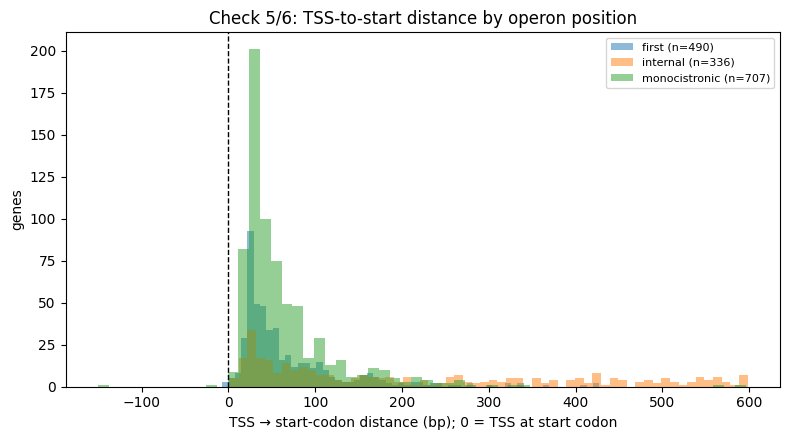

[7] TSS groups split across folds: 1 / 1452 (0.1%)  -> 28 leaking gene-pairs
      TSS RDBECOLIPMC03055: 8 genes across folds [5, 6]
[8] operon-internal genes sharing a TSS across folds: 7/1179 (0.6%)

>>> Positional CV is intentionally NOT leakage-controlled. The numbers above
    are the leakage the reference (composite-group) notebook removes. Read
    every §10 correlation as an upper bound inflated by this much overlap.

§5b complete (leakage reported, not asserted).


In [13]:
# ---------- §5b sanity checks ----------------------------------------------
EXPECT_ORIENT_FRAC = 0.90   # warn if < this for first/monocistronic mapped genes

mapped   = ann[ann.annotation_source == "regulondb"].copy()
fallback = ann[ann.annotation_source == "fallback"]
print(f"[1] RegulonDB-mapped genes : {len(mapped)} / {len(ann)} "
      f"({100*len(mapped)/len(ann):.1f}%)")
print(f"[2] start-codon fallback   : {len(fallback)} / {len(ann)} "
      f"({100*len(fallback)/len(ann):.1f}%)")

# [3]/[4] distinct vs shared operon-aware windows
oa_win = {}
for i in range(len(ann)):
    oa_win[ann.iloc[i].locus_tag] = make_window(ann.iloc[i], "operon_aware")
win_series = pd.Series(oa_win)
vc = win_series.value_counts()
n_unique = vc.size
n_shared_genes = int(vc[vc > 1].sum())
n_shared_grps  = int((vc > 1).sum())
print(f"[3] distinct operon-aware windows : {n_unique} for {len(ann)} genes")
print(f"[4] genes sharing an identical operon-aware window : {n_shared_genes} "
      f"in {n_shared_grps} window-groups (max group {int(vc.max())} genes)")

# TSS key: prefer promoter id, else (pos,strand). Genes with no selected TSS
# (fallback) are excluded from TSS-sharing logic.
def tss_key(tag):
    sel = GENE_TO_SELECTED_TSS.get(tag)
    if sel is None: return None
    pid, pos, st = sel
    return pid if (pid and str(pid) != "") else f"{pos}:{st}"

ann["_tss_key"] = ann.locus_tag.map(tss_key)
m = ann[ann._tss_key.notna()].copy()

# [5]/[6] TSS -> start-codon signed distance (transcription-directed, circular)
def signed_tss_to_start(row):
    sel = GENE_TO_SELECTED_TSS[row.locus_tag]
    _, pos, st = sel
    tss_anchor   = pos - 1
    start_anchor = gene_anchor_5p(row)
    raw = (start_anchor - tss_anchor) if st == "+" else (tss_anchor - start_anchor)
    # wrap to minimal circular distance
    raw = (raw + GENOME_LEN // 2) % GENOME_LEN - GENOME_LEN // 2
    return raw   # >0  => TSS upstream of the start codon (expected: 5'UTR)

m["_tss_dist"] = m.apply(signed_tss_to_start, axis=1)
print("\n[5] TSS->start-codon signed distance (bp, + = TSS upstream of start):")
for pos in ["first", "internal", "monocistronic"]:
    s = m.loc[m.operon_position == pos, "_tss_dist"]
    if len(s):
        q = s.quantile([0.05, 0.25, 0.5, 0.75, 0.95]).round(0).astype(int).tolist()
        print(f"    {pos:13s} n={len(s):4d}  "
              f"p05/p25/med/p75/p95 = {q}  (mean {s.mean():.0f})")

orient_ok = (m._tss_dist >= 0)
print("\n[6] fraction with TSS at/upstream of the gene's own 5' end:")
for pos in ["first", "internal", "monocistronic"]:
    sub = m[m.operon_position == pos]
    if len(sub):
        fr = float((sub._tss_dist >= 0).mean())
        print(f"    {pos:13s} {fr:6.1%}  (n={len(sub)})")
fm = m[m.operon_position.isin(["first", "monocistronic"])]
if len(fm):
    fr_fm = float((fm._tss_dist >= 0).mean())
    if fr_fm < EXPECT_ORIENT_FRAC:
        print(f"    ** WARNING: only {fr_fm:.1%} of first/monocistronic mapped "
              f"genes have an upstream TSS (< {EXPECT_ORIENT_FRAC:.0%}). "
              f"Likely a strand/coordinate misread in §3 — check the §3 "
              f"detector output and PR_POS_COL / PR_STRAND_COL overrides.")
    else:
        print(f"    OK: {fr_fm:.1%} of first/monocistronic mapped genes "
              f"have an upstream TSS.")

# figure: distance distribution by operon position
fig, ax = plt.subplots(figsize=(8, 4.5))
for pos, c in [("first", "tab:blue"), ("internal", "tab:orange"),
               ("monocistronic", "tab:green")]:
    s = m.loc[m.operon_position == pos, "_tss_dist"]
    s = s[s.between(-200, 600)]
    if len(s):
        ax.hist(s, bins=60, alpha=0.5, label=f"{pos} (n={len(s)})", color=c)
ax.axvline(0, color="k", lw=1, ls="--")
ax.set_xlabel("TSS → start-codon distance (bp); 0 = TSS at start codon")
ax.set_ylabel("genes"); ax.set_title("Check 5/6: TSS-to-start distance by operon position")
ax.legend(fontsize=8); fig.tight_layout()
fig.savefig(FIG_DIR / "sanity_tss_distance.png", dpi=150); plt.show()

# ---------- [7]/[8] LEAKAGE QUANTIFICATION (reported, NOT asserted) --------
# This is the deliberate difference vs. the reference notebook. The
# positional split applies no co-regulation grouping, so genes sharing a
# TSS CAN fall in different folds. We measure that leakage instead of
# failing on it.
fold_of = dict(zip(ann.locus_tag, ann.cv_fold))

cross_pairs, cross_keys = 0, []
for key, grp in m.groupby("_tss_key"):
    folds = {fold_of[t] for t in grp.locus_tag}
    if len(folds) > 1:
        k = len(grp)
        cross_pairs += k * (k - 1) // 2
        cross_keys.append((key, sorted(folds), k))

n_tss_groups = m["_tss_key"].nunique()
print(f"[7] TSS groups split across folds: {len(cross_keys)} / {n_tss_groups} "
      f"({100*len(cross_keys)/max(1,n_tss_groups):.1f}%)  "
      f"-> {cross_pairs} leaking gene-pairs")
for key, folds, k in cross_keys[:5]:
    print(f"      TSS {key}: {k} genes across folds {folds}")
if len(cross_keys) > 5:
    print(f"      ... and {len(cross_keys)-5} more")

key2folds = m.groupby("_tss_key").locus_tag.apply(lambda s: set(s.map(fold_of)))
internal = m[m.operon_position == "internal"]
bad = int(sum(len(key2folds[k]) > 1 for k in internal._tss_key))
frac_bad = bad / max(1, len(internal))
print(f"[8] operon-internal genes sharing a TSS across folds: "
      f"{bad}/{len(internal)} ({frac_bad:.1%})")

print("\n>>> Positional CV is intentionally NOT leakage-controlled. The "
      "numbers above\n    are the leakage the reference (composite-group) "
      "notebook removes. Read\n    every §10 correlation as an upper bound "
      "inflated by this much overlap.")

# Persist the leakage summary so §13 can save it alongside results.
LEAKAGE_SUMMARY = {
    "cv_scheme": "positional_8fold_sliding",
    "tss_groups_total": int(n_tss_groups),
    "tss_groups_cross_fold": int(len(cross_keys)),
    "leaking_gene_pairs": int(cross_pairs),
    "internal_genes_cross_fold": int(bad),
    "internal_genes_total": int(len(internal)),
    "internal_cross_fold_frac": float(frac_bad),
}

ann.drop(columns=["_tss_key"], inplace=True, errors="ignore")
print("\n§5b complete (leakage reported, not asserted).")

## 6. Encoders (AG + Evo)

In [14]:
if STAGE == "ag":
    from huggingface_hub import hf_hub_download
    AG_WEIGHTS = Path(hf_hub_download("gtca/alphagenome_pytorch", "model_all_folds.safetensors",
                                      cache_dir=str(CACHE_DIR), local_dir=str(CACHE_DIR)))
    from alphagenome_pytorch import AlphaGenome

    def load_ag():
        if hasattr(AlphaGenome, "from_pretrained"):
            return AlphaGenome.from_pretrained(str(AG_WEIGHTS)).to(DEVICE)
        import safetensors.torch
        m = AlphaGenome(); m.load_state_dict(safetensors.torch.load_file(str(AG_WEIGHTS)), strict=False)
        return m.to(DEVICE)

    def set_ag_trainable(m, t):
        for p in m.parameters(): p.requires_grad = False
        for p in m.encoder.parameters(): p.requires_grad = bool(t)
        m.encoder.gradient_checkpointing = bool(t); return m

    def ag_fwd(m, x, no_grad=True):
        ctx = torch.no_grad() if no_grad else torch.enable_grad()
        with ctx:
            return m.encoder(m.dtype_policy.cast_to_compute(x))[0]  # (B,1536,L/128)

    BASE2IDX = {b:i for i,b in enumerate("ACGT")}
    def one_hot(s):
        a = np.zeros((len(s),4), np.float32)
        for i,b in enumerate(s):
            j = BASE2IDX.get(b)
            if j is not None: a[i,j]=1.0
        return a
    AG_DIM = 1536

In [15]:
if STAGE == "evo":
    from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig
    EVO_REPO = "togethercomputer/evo-1-131k-base"
    evo_tok = AutoTokenizer.from_pretrained(EVO_REPO, trust_remote_code=True)
    evo_cfg = AutoConfig.from_pretrained(EVO_REPO, trust_remote_code=True, revision="main")
    evo_cfg.use_cache = False
    print("Loading Evo 1 (5-10 min first time)...")
    # NOTE: load in bfloat16, NOT float16. StripedHyena-7B's residual stream
    # grows with depth and routinely exceeds the fp16 max (~65504), so fp16
    # last-layer hidden states overflow to +/-inf -> NaN after pooling ->
    # poisoned feature cache -> the misleading "state_dict ... NoneType"
    # crash in fit_head. bf16 has the same 8-bit exponent as fp32
    # (max ~3.4e38) so these magnitudes cannot overflow; the reduced
    # mantissa is irrelevant for mean/last-token pooled features.
    # (Requires an Ampere+ GPU for native bf16 -- fine on H100.)
    evo_model = AutoModelForCausalLM.from_pretrained(
        EVO_REPO, config=evo_cfg, trust_remote_code=True,
        torch_dtype=torch.bfloat16, device_map="auto")
    evo_model.eval()
    for p in evo_model.parameters(): p.requires_grad = False
    EVO_DIM = evo_cfg.hidden_size
    print(f"Evo dim {EVO_DIM}, params {sum(p.numel() for p in evo_model.parameters())/1e9:.2f}B")

    @torch.no_grad()
    def evo_hidden(seq):
        ids = evo_tok.encode(seq, add_special_tokens=False, return_tensors="pt").to(DEVICE)
        try:
            h = evo_model(input_ids=ids, output_hidden_states=True,
                          return_dict=True).hidden_states[-1]
            return h.float()  # upcast bf16 -> fp32 before any pooling/casting
        except TypeError:
            pass
        cap = {}
        def hk(_m,_i,o): cap["h"] = o if isinstance(o, torch.Tensor) else o[0]
        tgt = None
        for a in ("backbone","model"):
            if hasattr(evo_model, a):
                inner = getattr(evo_model, a)
                if hasattr(inner,"blocks"): tgt = inner.blocks[-1]; break
                if hasattr(inner,"layers"): tgt = inner.layers[-1]; break
        h = tgt.register_forward_hook(hk)
        try:
            evo_model(input_ids=ids); return cap["h"].float()
        finally:
            h.remove()

In [16]:
if STAGE == "evo":
    import sys, torch

    print("Python:", sys.version)
    print("Torch:", torch.__version__)
    print("Torch CUDA:", torch.version.cuda)
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))

    try:
        from flash_attn.modules.mha import MHA
        print("flash_attn MHA import OK")
    except Exception as e:
        import traceback
        traceback.print_exc()

In [17]:
if STAGE == "evo":
    # Sanity check BEFORE the ~3 hr recompute: confirm bf16 keeps the
    # last-layer hidden state finite on the worst case, not just average.
    # (fp16 used to overflow here to +/-inf -> NaN-poisoned feature cache.)
    import torch
    _mx = 0.0
    for _i in (0, len(ann)//2, len(ann)-1):
        _seq = make_window(ann.iloc[_i], "naive")
        _h = evo_hidden(_seq)
        assert torch.isfinite(_h).all(), (
            f"row {_i} still non-finite in bf16 -- do NOT recompute the "
            f"cache yet; investigate the Evo forward pass first.")
        _mx = max(_mx, _h.abs().max().item())
    print(f"bf16 OK -- all finite, max|h| = {_mx:.1f} "
          f"(fp16 max is ~65504; bf16 max is ~3.4e38, so no overflow)")

## 7. Feature extraction per (encoder, window_mode)

Caches: AG × {naive, operon_aware}, Evo(mean/last) × {naive, operon_aware}. The full `[-500,+100]` window is used (the region ablation from the previous notebook is orthogonal and omitted here to keep the run tractable; add it back by looping over sub-regions if desired).

In [18]:
def agp(mode, tag):
    d = CACHE_DIR / f"ag_{mode}"; d.mkdir(exist_ok=True); return d / f"{tag}.npy"
def evmp(mode, tag):
    d = CACHE_DIR / f"evo_mean_{mode}"; d.mkdir(exist_ok=True); return d / f"{tag}.npy"
def evlp(mode, tag):
    d = CACHE_DIR / f"evo_last_{mode}"; d.mkdir(exist_ok=True); return d / f"{tag}.npy"

if STAGE == "ag":
    # --- AG features ---
    ag_model = load_ag(); set_ag_trainable(ag_model, False); ag_model.eval()
    n_new = 0
    for _, g in tqdm(ann.iterrows(), total=len(ann), desc="AG feats"):
        for mode in WINDOW_MODES:
            p = agp(mode, g.locus_tag)
            if p.exists(): continue
            seq = ag_pad(make_window(g, mode))
            x = torch.from_numpy(one_hot(seq)).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                v = ag_fwd(ag_model, x)[0].mean(-1).cpu().to(torch.float16).numpy()
            np.save(p, v); n_new += 1
    print(f"AG features computed: {n_new}")
    del ag_model; gc.collect(); torch.cuda.empty_cache()

AG feats: 100%|██████████| 3829/3829 [00:35<00:00, 108.49it/s]


AG features computed: 0


In [19]:
if STAGE == "evo":
    # The previous fp16 run poisoned EVERY evo_* feature file with NaN/Inf.
    # The feature loop below is idempotent (skip-if-exists), so it would
    # keep the corrupt files. Wipe all four dirs so they are recomputed in
    # fp32. Set FORCE_EVO_CACHE_RESET=False to skip (e.g. after a good run).
    import shutil
    FORCE_EVO_CACHE_RESET = False
    if FORCE_EVO_CACHE_RESET:
        for _d in ("evo_mean_naive", "evo_mean_operon_aware",
                   "evo_last_naive", "evo_last_operon_aware"):
            shutil.rmtree(CACHE_DIR / _d, ignore_errors=True)
        print("Cleared poisoned Evo caches (4 dirs) -- will recompute in fp32.")
    else:
        print("FORCE_EVO_CACHE_RESET=False -- keeping existing Evo cache.")

In [20]:
if STAGE == "evo":
    # --- Evo features (mean + last), both window modes ---
    # evo_hidden() now returns fp32 (bf16 model + .float()); pool and store
    # in fp32. The inline finite-check fails at the offending locus_tag
    # instead of surfacing 3 hours later as a NoneType crash in fit_head.
    n_new = 0
    for _, g in tqdm(ann.iterrows(), total=len(ann), desc="Evo feats"):
        for mode in WINDOW_MODES:
            mp, lp = evmp(mode, g.locus_tag), evlp(mode, g.locus_tag)
            if mp.exists() and lp.exists(): continue
            seq = make_window(g, mode)  # 600 bp, no AG padding for Evo
            h = evo_hidden(seq)
            mean_vec = h[0].float().mean(0).cpu().numpy().astype(np.float32)
            last_vec = h[0,-1,:].float().cpu().numpy().astype(np.float32)
            assert np.isfinite(mean_vec).all() and np.isfinite(last_vec).all(), (
                f"non-finite Evo feature for {g.locus_tag} (mode={mode}) -- "
                f"investigate the forward pass BEFORE caching; do not save.")
            np.save(mp, mean_vec)
            np.save(lp, last_vec)
            n_new += 1
    print(f"Evo features computed: {n_new}")
    del evo_model; gc.collect(); torch.cuda.empty_cache()

## 8. Head + CV runners

In [21]:
class GeneMLPHead(nn.Module):
    def __init__(self, d, h=256, p=0.1):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d,h), nn.GELU(), nn.Dropout(p), nn.Linear(h,1))
    def forward(self,x): return self.net(x).squeeze(-1)

def load_feats(path_fn, mode, idxs):
    # HARD ASSERTION: never silently drop a gene because its cached feature
    # file is absent. A missing cache shrinks the fold and corrupts the CV
    # comparison invisibly, so fail loudly and say exactly what to re-run.
    missing = [(int(i), ann.iloc[i].locus_tag, str(path_fn(mode, ann.iloc[i].locus_tag)))
               for i in idxs if not path_fn(mode, ann.iloc[i].locus_tag).exists()]
    if missing:
        kind = "AG" if "ag_" in str(path_fn(mode, ann.iloc[idxs[0]].locus_tag)) else "Evo"
        ex = ", ".join(f"{t} -> {p}" for _, t, p in missing[:5])
        raise FileNotFoundError(
            f"{len(missing)}/{len(idxs)} cached feature files missing for "
            f"(encoder={kind}, window_mode='{mode}'). Re-run the {kind} "
            f"feature-extraction cell (\u00a77) before CV; it is idempotent and "
            f"will only compute the gaps. First missing: {ex}"
            + (" ..." if len(missing) > 5 else ""))
    X, y, tags = [], [], []
    for i in idxs:
        g = ann.iloc[i]; p = path_fn(mode, g.locus_tag)
        X.append(np.load(p).astype(np.float32))
        y.append(g.log_tpm); tags.append(g.locus_tag)
    X = np.stack(X)
    assert len(X) == len(idxs) == len(y) == len(tags), \
        "load_feats lost rows despite the missing-file guard — investigate."
    return X, np.array(y, np.float32), np.array(tags)

def fit_head(Xtr,ytr,Xva,yva,d,epochs=200,bs=256,lr=1e-3,wd=1e-3):
    # GUARD 1: reject corrupt features up front with a readable message
    # naming the offender, instead of letting NaN flow into the loss ->
    # NaN weights -> NaN Spearman every epoch -> bs_state stays None ->
    # the misleading "Expected state_dict ... got NoneType" crash below.
    for nm, A in (("Xtr",Xtr),("Xva",Xva),("ytr",ytr),("yva",yva)):
        if not np.isfinite(A).all():
            bad = int((~np.isfinite(A)).sum())
            raise ValueError(
                f"fit_head: {nm} has {bad} non-finite value(s) -- the feature "
                f"cache is corrupt. Delete the relevant cache_rdb/* dir and "
                f"recompute (§7). This is NOT a model-head bug.")
    head = GeneMLPHead(d).to(DEVICE)
    opt = torch.optim.AdamW(head.parameters(), lr=lr, weight_decay=wd)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    Xt,yt = torch.from_numpy(Xtr).to(DEVICE), torch.from_numpy(ytr).to(DEVICE)
    Xv = torch.from_numpy(Xva).to(DEVICE)
    n=len(Xtr); best=-1.0; bs_state=None
    for e in range(epochs):
        head.train(); perm=torch.randperm(n,device=DEVICE)
        for i in range(0,n,bs):
            idx=perm[i:i+bs]
            loss=F.mse_loss(head(Xt[idx]), yt[idx])
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        sch.step(); head.eval()
        with torch.no_grad(): pv=head(Xv).cpu().numpy()
        r,_=spearmanr(pv,yva)
        # GUARD 2: NaN compares False, so an unguarded `r>best` would never
        # capture a state and bs_state would stay None. Require finite r.
        if np.isfinite(r) and r>best:
            best=r; bs_state={k:v.detach().clone() for k,v in head.state_dict().items()}
    # GUARD 3: degenerate fold (r never finite/improved) -> fall back to the
    # final weights rather than load_state_dict(None).
    if bs_state is None:
        bs_state = {k:v.detach().clone() for k,v in head.state_dict().items()}
    head.load_state_dict(bs_state); return head,best

def cv_frozen(name, path_fn, d, mode):
    res=[]
    for k in range(N_FOLDS):
        tr,va,te=split_for_fold(k)
        Xtr,ytr,_=load_feats(path_fn,mode,tr)
        Xva,yva,_=load_feats(path_fn,mode,va)
        Xte,yte,tags=load_feats(path_fn,mode,te)
        # Per-dim z-score from TRAIN ONLY (no leakage). Evo's StripedHyena
        # residual stream has a few ~1e3-1e4 'massive activation' dims;
        # mean-pooled and unnormalized they swamp the MLP input so the head
        # collapses to E[y] -> constant test predictions -> undefined
        # Spearman/Pearson (the ConstantInputWarning). AG's encoder output
        # is ~O(1), which is why only evo_mean failed before this fix.
        mu = Xtr.mean(0, keepdims=True)
        sd = Xtr.std(0, keepdims=True)
        sd[sd < 1e-6] = 1.0          # don't amplify (near-)constant dims
        Xtr = ((Xtr - mu) / sd).astype(np.float32)
        Xva = ((Xva - mu) / sd).astype(np.float32)
        Xte = ((Xte - mu) / sd).astype(np.float32)
        head,bv=fit_head(Xtr,ytr,Xva,yva,d); head.eval()
        with torch.no_grad(): pte=head(torch.from_numpy(Xte).to(DEVICE)).cpu().numpy()
        rs,_=spearmanr(pte,yte); rp,_=pearsonr(pte,yte)
        res.append({"fold":k,"test_spearman":float(rs),"test_pearson":float(rp),
                    "test_pred":pte,"test_true":yte,"test_tags":tags})
    sp=[r["test_spearman"] for r in res]; pe=[r["test_pearson"] for r in res]
    print(f"  {name}|{mode}: Spearman {np.mean(sp):+.3f}±{np.std(sp):.3f}  "
          f"Pearson {np.mean(pe):+.3f}±{np.std(pe):.3f}")
    return res

In [22]:
class WinDS(Dataset):
    def __init__(self, idxs, mode):
        self.idxs=idxs; self.mode=mode
    def __len__(self): return len(self.idxs)
    def __getitem__(self,i):
        g=ann.iloc[self.idxs[i]]
        seq=ag_pad(make_window(g,self.mode))
        return {"x":torch.from_numpy(one_hot(seq)),"y":float(g.log_tpm),"tag":g.locus_tag}
def coll(b):
    return {"x":torch.stack([z["x"] for z in b]),
            "y":torch.tensor([z["y"] for z in b],dtype=torch.float32),
            "tags":[z["tag"] for z in b]}

def cv_ag_unfrozen(mode, epochs=5, enc_lr=1e-5, head_lr=1e-3):
    res=[]
    for k in range(N_FOLDS):
        tr,va,te=split_for_fold(k)
        tl=DataLoader(WinDS(tr,mode),batch_size=16,shuffle=True,collate_fn=coll,num_workers=2)
        vl=DataLoader(WinDS(va,mode),batch_size=16,shuffle=False,collate_fn=coll,num_workers=2)
        el=DataLoader(WinDS(te,mode),batch_size=16,shuffle=False,collate_fn=coll,num_workers=2)
        m=load_ag(); set_ag_trainable(m,True); head=GeneMLPHead(AG_DIM).to(DEVICE)
        opt=torch.optim.AdamW([{"params":m.encoder.parameters(),"lr":enc_lr},
                               {"params":head.parameters(),"lr":head_lr}], weight_decay=1e-4)
        sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs)
        def run(loader,train):
            m.train(train); head.train(train)
            P,Y,T=[],[],[]
            cm=torch.enable_grad() if train else torch.no_grad()
            with cm:
                for b in loader:
                    x=b["x"].to(DEVICE); y=b["y"].to(DEVICE)
                    f=ag_fwd(m,x,no_grad=not train).mean(-1)
                    pr=head(f)
                    if train:
                        l=F.mse_loss(pr,y); opt.zero_grad(set_to_none=True); l.backward()
                        torch.nn.utils.clip_grad_norm_(
                            list(m.encoder.parameters())+list(head.parameters()),1.0)
                        opt.step()
                    P.append(pr.detach().cpu().numpy()); Y.append(y.cpu().numpy()); T+=b["tags"]
            return np.concatenate(P),np.concatenate(Y),np.array(T)
        best=-1; bstate=None
        for e in range(epochs):
            run(tl,True); sch.step()
            pv,yv,_=run(vl,False); r,_=spearmanr(pv,yv)
            if r>best: best=r; bstate={
                "e":{k_:v.cpu().clone() for k_,v in m.encoder.state_dict().items()},
                "h":{k_:v.cpu().clone() for k_,v in head.state_dict().items()}}
        m.encoder.load_state_dict(bstate["e"]); head.load_state_dict(bstate["h"])
        pte,yte,tags=run(el,False)
        rs,_=spearmanr(pte,yte); rp,_=pearsonr(pte,yte)
        res.append({"fold":k,"test_spearman":float(rs),"test_pearson":float(rp),
                    "test_pred":pte,"test_true":yte,"test_tags":tags})
        del m,head; gc.collect(); torch.cuda.empty_cache()
    sp=[r["test_spearman"] for r in res]
    print(f"  AG_unfrozen|{mode}: Spearman {np.mean(sp):+.3f}±{np.std(sp):.3f}")
    return res

## 9. Run all configurations × both window modes

In [23]:
results = {}  # (config, mode) -> folds
for mode in WINDOW_MODES:
    print(f"\n##### WINDOW MODE: {mode} #####")
    results[("AG_frozen", mode)] = cv_frozen("AG_frozen", agp, AG_DIM, mode)
    results[("Evo_mean", mode)]  = cv_frozen("Evo_mean", evmp, EVO_DIM, mode)
    results[("Evo_last", mode)]  = cv_frozen("Evo_last", evlp, EVO_DIM, mode)


##### WINDOW MODE: naive #####
  AG_frozen|naive: Spearman +0.313±0.074  Pearson +0.332±0.082
  Evo_mean|naive: Spearman +0.254±0.082  Pearson +0.269±0.094
  Evo_last|naive: Spearman +0.292±0.054  Pearson +0.303±0.050

##### WINDOW MODE: operon_aware #####
  AG_frozen|operon_aware: Spearman +0.244±0.079  Pearson +0.263±0.077
  Evo_mean|operon_aware: Spearman +0.175±0.062  Pearson +0.185±0.073
  Evo_last|operon_aware: Spearman +0.181±0.031  Pearson +0.193±0.024


In [24]:
if STAGE == "ag":
    for mode in WINDOW_MODES:
        print(f"\n##### AG UNFROZEN: {mode} #####")
        results[("AG_unfrozen", mode)] = cv_ag_unfrozen(mode, epochs=5)


##### AG UNFROZEN: naive #####
  AG_unfrozen|naive: Spearman +0.346±0.088

##### AG UNFROZEN: operon_aware #####
  AG_unfrozen|operon_aware: Spearman +0.299±0.079


In [25]:
# ============================================================================
#  DROP-IN CELL — improvements 1–5, comparable in-place against `results`
# ----------------------------------------------------------------------------
#  1. per-position features + learned attention pool (no mean-pool collapse)
#  2. gene-body / CDS window block, concatenated with the promoter window
#  3. RidgeCV / PCA→Ridge baseline for the frozen high-dim features
#  4. better AG fine-tune: top-K block unfreeze, grad-accum, more epochs,
#     attention-pool head
#  5. Spearman-aligned objective: y standardized, Huber + soft-Spearman loss
#
#  Paste this AFTER §9 (and, if present, after the AG-unfrozen cell so that
#  `results` exists). It never mutates `results`, `ann`, or the original
#  cache dirs; everything new lands in `results_v2` and `cache_rdb/pp_*`.
#
#  TWO-PASS, identical contract to §7/§9:
#    • evo kernel (NB_STAGE=evo): run once -> new Evo features cached -> STOP.
#    • ag  kernel (NB_STAGE=ag) : run once -> new AG features cached, then all
#      v2 CV runners + the side-by-side comparison execute (needs both caches).
# ============================================================================
import shutil
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.decomposition import PCA

#TO RUN
# 1. Set venv to bacteria8/evo and set STAGE to "evo" => run sections 1-7 including 7 => run this cell
# 2. Set venv to bacteria8/ag and set STAGE to "ag" => run all

 
# ---- knobs -----------------------------------------------------------------
USE_CDS           = True     # change 2: add the gene-body block. Costs an
                             # extra feature-extraction pass per encoder.
CDS_WIN_BP        = 600      # bp downstream of the start codon (gene body)
NEWFEAT_EVO_BINS  = 16       # change 1: Evo positional summary resolution
V2_PROMOTER_MODES = ["naive", "operon_aware"]
LAMBDA_RANK       = 0.5      # change 5: weight of the soft-Spearman term
HEAD_WIDTH        = 256
HEAD_DROP         = 0.30     # change 3: stronger reg than the original 0.1
HEAD_WD           = 1e-2
FROZEN_EPOCHS     = 300
FROZEN_PATIENCE   = 40
UNFREEZE_TOP_K    = 4        # change 4: # of top AG encoder blocks to unfreeze
AGUF_EPOCHS       = 20
AGUF_ACCUM        = 4        # effective batch = 16 * 4 = 64
AGUF_PATIENCE     = 6
RUN_AG_UNFROZEN   = True     # the slow GPU part; set False to skip on ag pass
 
ALL_V2_MODES = list(V2_PROMOTER_MODES) + (["cds"] if USE_CDS else [])
 
# ---- new, additive cache layout (original dirs are never touched) ----------
def pp_ag(mode, tag):
    d = CACHE_DIR / f"pp_ag_{mode}";  d.mkdir(exist_ok=True); return d / f"{tag}.npy"
def pp_ev(mode, tag):
    d = CACHE_DIR / f"pp_evo_{mode}"; d.mkdir(exist_ok=True); return d / f"{tag}.npy"
 
# ---- change 2: gene-body window (start-codon -> +CDS_WIN_BP, mRNA oriented) -
def make_cds_window(g_row, win_bp=CDS_WIN_BP):
    anchor, strand = gene_anchor_5p(g_row), g_row.strand
    if strand == "+":
        return circ(anchor, win_bp)
    return revcomp(circ(anchor - win_bp + 1, win_bp))
 
def _win_seq(g, mode):
    return make_cds_window(g) if mode == "cds" else make_window(g, mode)
 

# --- self-heal: §7 ends with `del evo_model`, so reload Evo if it's gone ---
if STAGE == "evo" and ("evo_model" not in globals() or "evo_hidden" not in globals()):
    print("evo_model was freed by §7; reloading Evo for the v2 recompute...")
    from transformers import AutoTokenizer, AutoModelForCausalLM, AutoConfig
    EVO_REPO = "togethercomputer/evo-1-131k-base"
    evo_tok = AutoTokenizer.from_pretrained(EVO_REPO, trust_remote_code=True)
    evo_cfg = AutoConfig.from_pretrained(EVO_REPO, trust_remote_code=True, revision="main")
    evo_cfg.use_cache = False
    evo_model = AutoModelForCausalLM.from_pretrained(
        EVO_REPO, config=evo_cfg, trust_remote_code=True,
        torch_dtype=torch.bfloat16, device_map="auto")
    evo_model.eval()
    for p in evo_model.parameters():
        p.requires_grad = False

    @torch.no_grad()
    def evo_hidden(seq):
        ids = evo_tok.encode(seq, add_special_tokens=False,
                             return_tensors="pt").to(DEVICE)
        try:
            h = evo_model(input_ids=ids, output_hidden_states=True,
                          return_dict=True).hidden_states[-1]
            return h.float()
        except TypeError:
            pass
        cap = {}
        def hk(_m, _i, o):
            cap["h"] = o if isinstance(o, torch.Tensor) else o[0]
        tgt = None
        for a in ("backbone", "model"):
            if hasattr(evo_model, a):
                inner = getattr(evo_model, a)
                if hasattr(inner, "blocks"):
                    tgt = inner.blocks[-1]; break
                if hasattr(inner, "layers"):
                    tgt = inner.layers[-1]; break
        hk_h = tgt.register_forward_hook(hk)
        try:
            evo_model(input_ids=ids); return cap["h"].float()
        finally:
            hk_h.remove()

# ============================================================================
#  FEATURE EXTRACTION  (per STAGE, idempotent skip-if-exists, like §7)
# ============================================================================
if STAGE == "ag":
    _agm = load_ag(); set_ag_trainable(_agm, False); _agm.eval()
    _n = 0
    for _, _g in tqdm(ann.iterrows(), total=len(ann), desc="AG pp-feats"):
        for _m in ALL_V2_MODES:
            _p = pp_ag(_m, _g.locus_tag)
            if _p.exists():
                continue
            _seq = ag_pad(_win_seq(_g, _m))
            _x = torch.from_numpy(one_hot(_seq)).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                _v = ag_fwd(_agm, _x)[0]                       # (1536, T)
            _v = _v.transpose(0, 1).contiguous().cpu().to(torch.float16).numpy()
            np.save(_p, _v)                                    # (T, 1536)
            _n += 1
    print(f"AG per-position features written: {_n}")
    del _agm; gc.collect(); torch.cuda.empty_cache()
 
if STAGE == "evo":
    # Same forward pass as §7; only the pooling differs. Stores a
    # NEWFEAT_EVO_BINS x 4096 mean-binned summary instead of one mean vector,
    # so the head can learn WHERE in the window the signal is.
    _n = 0
    for _, _g in tqdm(ann.iterrows(), total=len(ann), desc="Evo pp-feats"):
        for _m in ALL_V2_MODES:
            _p = pp_ev(_m, _g.locus_tag)
            if _p.exists():
                continue
            _hn = evo_hidden(_win_seq(_g, _m))[0].float().cpu().numpy()  # (T,4096)
            _B = min(NEWFEAT_EVO_BINS, _hn.shape[0])
            _v = np.stack([c.mean(0) for c in np.array_split(_hn, _B, axis=0)]
                          ).astype(np.float32)                 # (B, 4096)
            assert np.isfinite(_v).all(), \
                f"non-finite Evo pp feat {_g.locus_tag}/{_m} -- do not cache"
            np.save(_p, _v)
            _n += 1
    print(f"Evo per-position(binned) features written: {_n}")
    print(">>> evo pass done. Switch to the ag kernel and re-run this cell "
          "for the v2 CV + comparison.")
 
# ============================================================================
#  HEADS, LOSS, LOADERS  (defined on both kernels; only used on ag)
# ============================================================================
class AttnHead(nn.Module):
    """Per-mode learned-query attention pool -> concat -> small MLP.
    Consumes {mode: (B, T, D)} with arbitrary, per-mode T."""
    def __init__(self, d, modes, h=HEAD_WIDTH, p=HEAD_DROP):
        super().__init__()
        self.modes = list(modes)
        self.q  = nn.ParameterDict(
            {m: nn.Parameter(torch.randn(d) * d ** -0.5) for m in self.modes})
        self.ln = nn.LayerNorm(d)
        self.mlp = nn.Sequential(
            nn.Linear(d * len(self.modes), h), nn.GELU(),
            nn.Dropout(p), nn.Linear(h, 1))
 
    def forward(self, feats):
        pooled = []
        for m in self.modes:
            X = self.ln(feats[m])                               # (B,T,D)
            s = (X @ self.q[m]) * (X.shape[-1] ** -0.5)         # (B,T)
            a = torch.softmax(s, dim=1).unsqueeze(-1)           # (B,T,1)
            pooled.append((a * X).sum(1))                       # (B,D)
        return self.mlp(torch.cat(pooled, -1)).squeeze(-1)
 
def _soft_rank(x, temp=0.1):
    d = x.unsqueeze(0) - x.unsqueeze(1)                         # x_j - x_i
    return torch.sigmoid(d / temp).sum(0)                       # ~ rank_i
 
def soft_spearman(pred, y, temp=0.1, eps=1e-6):
    rp, ry = _soft_rank(pred, temp), _soft_rank(y, temp)
    rp = rp - rp.mean(); ry = ry - ry.mean()
    return (rp * ry).sum() / (rp.norm() * ry.norm() + eps)
 
def _load_pp(path_fn, mode, idxs):
    miss = [ann.iloc[i].locus_tag for i in idxs
            if not path_fn(mode, ann.iloc[i].locus_tag).exists()]
    if miss:
        raise FileNotFoundError(
            f"{len(miss)}/{len(idxs)} v2 feature files missing (mode={mode}). "
            f"Re-run this cell on the matching kernel (idempotent). "
            f"e.g. {miss[:3]}")
    X = [np.load(path_fn(mode, ann.iloc[i].locus_tag)).astype(np.float32)
         for i in idxs]
    y = np.array([ann.iloc[i].log_tpm for i in idxs], np.float32)
    t = np.array([ann.iloc[i].locus_tag for i in idxs])
    return X, y, t
 
def _zfit(Xlist):                                              # train-only
    A = np.concatenate(Xlist, 0)                               # (N*T, D)
    mu = A.mean(0, keepdims=True)
    sd = A.std(0, keepdims=True); sd[sd < 1e-6] = 1.0
    return mu.astype(np.float32), sd.astype(np.float32)
 
def _zapply(X, mu, sd):
    return ((X - mu) / sd).astype(np.float32)
 
def _fit_pooled(TR, ytr, VA, yva, modes, d):
    ymu, ysd = float(ytr.mean()), float(ytr.std() + 1e-8)      # change 5
    yt = torch.tensor((ytr - ymu) / ysd, device=DEVICE)
    Ft = {m: torch.tensor(TR[m], device=DEVICE) for m in modes}
    Fv = {m: torch.tensor(VA[m], device=DEVICE) for m in modes}
    head = AttnHead(d, modes).to(DEVICE)
    opt = torch.optim.AdamW(head.parameters(), lr=1e-3, weight_decay=HEAD_WD)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FROZEN_EPOCHS)
    n, best, bstate, bad = len(ytr), -1.0, None, 0
    for _e in range(FROZEN_EPOCHS):
        head.train(); perm = torch.randperm(n, device=DEVICE)
        for i in range(0, n, 256):
            idx = perm[i:i + 256]
            p = head({m: Ft[m][idx] for m in modes})
            tgt = yt[idx]
            loss = F.smooth_l1_loss(p, tgt)
            if len(idx) > 8:
                loss = loss + LAMBDA_RANK * (1 - soft_spearman(p, tgt))
            opt.zero_grad(set_to_none=True); loss.backward(); opt.step()
        sch.step(); head.eval()
        with torch.no_grad():
            pv = head(Fv).cpu().numpy()
        r, _ = spearmanr(pv, yva)
        if np.isfinite(r) and r > best:
            best = r; bad = 0
            bstate = {k: v.detach().clone()
                      for k, v in head.state_dict().items()}
        else:
            bad += 1
            if bad >= FROZEN_PATIENCE:
                break
    if bstate is None:
        bstate = {k: v.detach().clone() for k, v in head.state_dict().items()}
    head.load_state_dict(bstate)
    return head
 
def cv_frozen_v2(name, path_fn, d, modes):
    res = []
    for k in range(N_FOLDS):
        tr, va, te = split_for_fold(k)
        TR, VA, TE = {}, {}, {}
        ytr = yva = yte = tg = None
        for m in modes:
            Xtr, ytr, _ = _load_pp(path_fn, m, tr)
            Xva, yva, _ = _load_pp(path_fn, m, va)
            Xte, yte, tg = _load_pp(path_fn, m, te)
            mu, sd = _zfit(Xtr)
            TR[m] = np.stack([_zapply(x, mu, sd) for x in Xtr])
            VA[m] = np.stack([_zapply(x, mu, sd) for x in Xva])
            TE[m] = np.stack([_zapply(x, mu, sd) for x in Xte])
        head = _fit_pooled(TR, ytr, VA, yva, modes, d); head.eval()
        with torch.no_grad():
            pte = head({m: torch.tensor(TE[m], device=DEVICE)
                        for m in modes}).cpu().numpy()
        rs, _ = spearmanr(pte, yte); rp, _ = pearsonr(pte, yte)
        res.append({"fold": k, "test_spearman": float(rs),
                    "test_pearson": float(rp), "test_pred": pte,
                    "test_true": yte, "test_tags": tg})
    sp = [r["test_spearman"] for r in res]
    print(f"  {name}: Spearman {np.mean(sp):+.3f}±{np.std(sp):.3f}")
    return res
 
def cv_ridge(name, path_fn, mode, use_pca=False, n_comp=256):
    # change 3 — runs on the ORIGINAL mean-pool cache, so it is free and
    # needs no recompute. `load_feats` is the notebook's §8 loader.
    res = []
    for k in range(N_FOLDS):
        tr, va, te = split_for_fold(k)
        Xtr, ytr, _ = load_feats(path_fn, mode, tr)
        Xte, yte, tg = load_feats(path_fn, mode, te)
        mu = Xtr.mean(0, keepdims=True)
        sd = Xtr.std(0, keepdims=True); sd[sd < 1e-6] = 1.0
        Xtr = (Xtr - mu) / sd; Xte = (Xte - mu) / sd
        if use_pca and Xtr.shape[1] > n_comp:
            pca = PCA(n_components=n_comp, random_state=42).fit(Xtr)
            Xtr, Xte = pca.transform(Xtr), pca.transform(Xte)
        reg = RidgeCV(alphas=np.logspace(-1, 4, 20)).fit(Xtr, ytr)
        pte = reg.predict(Xte)
        rs, _ = spearmanr(pte, yte); rp, _ = pearsonr(pte, yte)
        res.append({"fold": k, "test_spearman": float(rs),
                    "test_pearson": float(rp), "test_pred": pte,
                    "test_true": yte, "test_tags": tg})
    sp = [r["test_spearman"] for r in res]
    print(f"  {name}: Spearman {np.mean(sp):+.3f}±{np.std(sp):.3f}")
    return res
 
def _ag_blocks(enc):
    cand = None
    for a in ("blocks", "layers"):
        if hasattr(enc, a):
            cand = getattr(enc, a); break
    if cand is None:
        for a in ("transformer", "trunk", "net"):
            s = getattr(enc, a, None)
            if s is None:
                continue
            for b in ("blocks", "layers"):
                if hasattr(s, b):
                    cand = getattr(s, b); break
            if cand is not None:
                break
    try:
        len(cand); return list(cand)
    except Exception:
        return None
 
def cv_ag_unfrozen_v2(mode, enc_lr=2e-5, head_lr=1e-3):
    res = []
    for k in range(N_FOLDS):
        tr, va, te = split_for_fold(k)
        tl = DataLoader(WinDS(tr, mode), batch_size=16, shuffle=True,
                        collate_fn=coll, num_workers=2)
        vl = DataLoader(WinDS(va, mode), batch_size=16, shuffle=False,
                        collate_fn=coll, num_workers=2)
        el = DataLoader(WinDS(te, mode), batch_size=16, shuffle=False,
                        collate_fn=coll, num_workers=2)
        m = load_ag()
        for p in m.parameters():
            p.requires_grad = False
        blocks = _ag_blocks(m.encoder)
        if blocks is None:
            print("  [warn] AG encoder block list not found; unfreezing the "
                  "full encoder (still valid, just heavier).")
            for p in m.encoder.parameters():
                p.requires_grad = True
            enc_params = list(m.encoder.parameters())
        else:
            for blk in blocks[-UNFREEZE_TOP_K:]:
                for p in blk.parameters():
                    p.requires_grad = True
            enc_params = [p for blk in blocks[-UNFREEZE_TOP_K:]
                          for p in blk.parameters()]
        m.encoder.gradient_checkpointing = True
        head = AttnHead(AG_DIM, [mode]).to(DEVICE)
        opt = torch.optim.AdamW(
            [{"params": enc_params, "lr": enc_lr},
             {"params": head.parameters(), "lr": head_lr}], weight_decay=1e-4)
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=AGUF_EPOCHS)
        ytr_all = np.array([ann.iloc[i].log_tpm for i in tr], np.float32)
        ymu, ysd = float(ytr_all.mean()), float(ytr_all.std() + 1e-8)
 
        def run(loader, train):
            m.train(train); head.train(train)
            P, Y, T = [], [], []
            cm = torch.enable_grad() if train else torch.no_grad()
            with cm:
                opt.zero_grad(set_to_none=True)
                for bi, b in enumerate(loader):
                    x = b["x"].to(DEVICE); y = b["y"].to(DEVICE)
                    f = ag_fwd(m, x, no_grad=not train)         # (B,1536,T)
                    f = f.transpose(1, 2).contiguous()          # (B,T,1536)
                    pr = head({mode: f})
                    if train:
                        tgt = (y - ymu) / ysd
                        l = F.smooth_l1_loss(pr, tgt)
                        if len(y) > 8:
                            l = l + LAMBDA_RANK * (1 - soft_spearman(pr, tgt))
                        (l / AGUF_ACCUM).backward()
                        if (bi + 1) % AGUF_ACCUM == 0:
                            torch.nn.utils.clip_grad_norm_(
                                enc_params + list(head.parameters()), 1.0)
                            opt.step(); opt.zero_grad(set_to_none=True)
                    P.append(pr.detach().cpu().numpy())
                    Y.append(y.cpu().numpy()); T += b["tags"]
                if train:
                    opt.step(); opt.zero_grad(set_to_none=True)
            return np.concatenate(P), np.concatenate(Y), np.array(T)
 
        best, bstate, bad = -1.0, None, 0
        for _e in range(AGUF_EPOCHS):
            run(tl, True); sch.step()
            pv, yv, _ = run(vl, False)
            r, _ = spearmanr(pv, yv)
            if np.isfinite(r) and r > best:
                best = r; bad = 0
                bstate = {
                    "e": {kk: vv.cpu().clone()
                          for kk, vv in m.encoder.state_dict().items()},
                    "h": {kk: vv.cpu().clone()
                          for kk, vv in head.state_dict().items()}}
            else:
                bad += 1
                if bad >= AGUF_PATIENCE:
                    break
        if bstate is not None:
            m.encoder.load_state_dict(bstate["e"])
            head.load_state_dict(bstate["h"])
        pte, yte, tg = run(el, False)
        rs, _ = spearmanr(pte, yte); rp, _ = pearsonr(pte, yte)
        res.append({"fold": k, "test_spearman": float(rs),
                    "test_pearson": float(rp), "test_pred": pte,
                    "test_true": yte, "test_tags": tg})
        del m, head; gc.collect(); torch.cuda.empty_cache()
    sp = [r["test_spearman"] for r in res]
    print(f"  AG_unfrozen_v2|{mode}: Spearman {np.mean(sp):+.3f}±{np.std(sp):.3f}")
    return res
 
# ============================================================================
#  RUN  (ag kernel only — needs both feature caches present)
# ============================================================================
if STAGE != "ag":
    print("\nevo kernel: new Evo features are cached. Stop here, switch to "
          "the ag kernel, and re-run this cell to get v2 CV + comparison.")
else:
    results_v2 = {}
    for mode in V2_PROMOTER_MODES:
        print(f"\n##### v2  WINDOW MODE: {mode} #####")
        results_v2[("AG_frozen_attn", mode)] = cv_frozen_v2(
            "AG_frozen_attn", pp_ag, AG_DIM, [mode])              # ch.1
        results_v2[("Evo_attn", mode)] = cv_frozen_v2(
            "Evo_attn", pp_ev, EVO_DIM, [mode])                   # ch.1
        results_v2[("AG_ridge", mode)] = cv_ridge(
            "AG_ridge", agp, mode, use_pca=False)                 # ch.3
        results_v2[("Evo_ridge", mode)] = cv_ridge(
            "Evo_ridge", evmp, mode, use_pca=True)                # ch.3
        if RUN_AG_UNFROZEN:
            results_v2[("AG_unfrozen_v2", mode)] = cv_ag_unfrozen_v2(mode)  # ch.4
 
    if USE_CDS:                                                  # ch.2
        for mode in V2_PROMOTER_MODES:
            tag = f"{mode}+cds"
            print(f"\n##### v2  promoter+gene-body concat: {tag} #####")
            results_v2[(f"AG_attn_{tag}", "combo")] = cv_frozen_v2(
                f"AG_attn_{tag}", pp_ag, AG_DIM, [mode, "cds"])
            results_v2[(f"Evo_attn_{tag}", "combo")] = cv_frozen_v2(
                f"Evo_attn_{tag}", pp_ev, EVO_DIM, [mode, "cds"])
 
    # ---- side-by-side vs the existing `results` ----------------------------
    def _ms(fr):
        s = [r["test_spearman"] for r in fr]
        return float(np.mean(s)), float(np.std(s))
 
    print("\n=============== v2 vs current (test Spearman) ===============")
    if "results" in globals():
        base_for = {"AG_frozen_attn": "AG_frozen", "AG_ridge": "AG_frozen",
                    "Evo_attn": "Evo_mean", "Evo_ridge": "Evo_mean",
                    "AG_unfrozen_v2": "AG_unfrozen"}
        print(f"{'config':20s}{'window':14s}"
              f"{'base ρ':>9s}{'v2 ρ':>9s}{'Δ':>8s}")
        for (cfg, mode), fr in results_v2.items():
            nm, _ = _ms(fr)
            b = base_for.get(cfg)
            if b and (b, mode) in results:
                om, _ = _ms(results[(b, mode)])
                print(f"{cfg:20s}{str(mode):14s}"
                      f"{om:>9.3f}{nm:>9.3f}{nm - om:>+8.3f}")
            else:
                print(f"{cfg:20s}{str(mode):14s}"
                      f"{'  n/a':>9s}{nm:>9.3f}{'':>8s}")
    else:
        for (cfg, mode), fr in results_v2.items():
            nm, ns = _ms(fr)
            print(f"  {cfg:20s}{str(mode):14s} ρ={nm:+.3f}±{ns:.3f}")
 
    print("\nStill the leaky positional split (§5b). Pooling/CDS/ridge/loss "
          "gains are representational and should transfer to the\n"
          "composite-group notebook; cross-fold leakage is not skill.")

AG pp-feats:  88%|████████▊ | 3370/3829 [00:46<00:05, 77.10it/s] 

AG pp-feats: 100%|██████████| 3829/3829 [00:52<00:00, 72.73it/s] 


AG per-position features written: 0

##### v2  WINDOW MODE: naive #####
  AG_frozen_attn: Spearman +0.347±0.083
  Evo_attn: Spearman +0.390±0.093
  AG_ridge: Spearman +0.372±0.076
  Evo_ridge: Spearman +0.385±0.091
  [warn] AG encoder block list not found; unfreezing the full encoder (still valid, just heavier).
  [warn] AG encoder block list not found; unfreezing the full encoder (still valid, just heavier).
  [warn] AG encoder block list not found; unfreezing the full encoder (still valid, just heavier).
  [warn] AG encoder block list not found; unfreezing the full encoder (still valid, just heavier).
  [warn] AG encoder block list not found; unfreezing the full encoder (still valid, just heavier).
  [warn] AG encoder block list not found; unfreezing the full encoder (still valid, just heavier).
  [warn] AG encoder block list not found; unfreezing the full encoder (still valid, just heavier).
  [warn] AG encoder block list not found; unfreezing the full encoder (still valid, just hea

## 9b. K-mer Ridge baseline (1–6 mers) — do the AG / Evo embeddings beat raw composition?

A **5,460-feature** ridge regression on k-mer counts is the standard sequence
baseline for "does this fancy embedding contain information above local
composition?".  Concretely, the features are:

| k | # k-mers | cumulative |
|---|---:|---:|
| 1 |    4 |    4 |
| 2 |   16 |   20 |
| 3 |   64 |   84 |
| 4 |  256 |  340 |
| 5 | 1,024 | 1,364 |
| 6 | 4,096 | 5,460 |

### What this baseline tests and what it does NOT test
This answers: *for this windowing (600 bp) and this CV (positional 8-fold),
does an AG / Evo embedding fed to a small MLP beat a linear model on raw
1-6 mer composition of the same window?*

It does **not** answer "are the embeddings useless".  Two confounds:

1. **Pooling.**  The §9 numbers use a `1536-d` or `4096-d` **mean-pooled**
   feature → small MLP.  The §39 (v2) cell already shows that attention-pool
   + CDS concat lifts AG to ρ≈0.50 — well above any mean-pool number.
   A k-mer-ties-encoder result is therefore consistent with *mean-pool
   destroying signal*, not with the embedding being uninformative.  The
   plots below also compare against the v2 attention-pool configs when
   `results_v2` is in scope so this distinction is visible.

2. **Leakage.**  §5b reports **1,395 / 3,829** genes share an *identical*
   `operon_aware` window with another gene.  Under positional CV these
   routinely cross folds → ridge gets perfect-memorization features when
   that happens.  The encoder MLPs face the same leakage, so the
   *comparison* stays fair, but absolute ρ — and especially the
   `operon_aware` ρ — is inflated for all of them, more so for ridge than
   for a regularised MLP.  Re-run under the composite-group reference
   notebook for a clean baseline.

### Other design decisions (flagged as constants below for easy override)
- **Strand-aware**: k-mers are counted on the same mRNA-oriented window the
  encoders see (`make_window`), not on the canonical (lex-min of fwd/rc)
  k-mer space.  This matches what AG / Evo are fed.
- **N handling**: k-mers containing N are not in the vocabulary, so they
  are dropped silently (only relevant if a window touches a gap).
- **Normalization**: each k-block is divided by the per-row count of
  positions where a k-mer of that k can start (`L - k + 1`), so the 4-mer
  block doesn't dominate the 1-mer block on scale.  Then per-feature
  z-score from **train only** (matches §8's `cv_frozen`).
- **Ridge alpha**: `sklearn.RidgeCV` over `np.logspace(-1, 4, 20)` —
  identical grid to §39's `cv_ridge` on the encoder features.
- **Cache location**: `cache_rdb/kmer_1_6/{naive,operon_aware}/<locus_tag>.npy`
  — additive, never touches the AG / Evo caches.

The cell stores results under `("Kmer_ridge", mode)` in the *existing*
`results` dict, so §10's stratified-analysis loop and §12's annotated-only
table pick it up automatically; nothing downstream needs editing.


In [26]:
# ============================================================================
# 9b. K-MER RIDGE BASELINE  —  feature extract + RidgeCV per fold
# ============================================================================
import time
from itertools import product
from sklearn.linear_model import RidgeCV
from sklearn.feature_extraction.text import CountVectorizer

# ---- knobs (defensible defaults, flagged for easy override) ---------------
KMER_KS         = (1, 2, 3, 4, 5, 6)
KMER_ALPHA_GRID = np.logspace(-1, 4, 20)   # matches §39 cv_ridge
KMER_NORMALIZE  = "per_k_frequency"        # "raw" | "per_k_frequency"

# ---- fixed vocabulary so every gene maps to the same column space ---------
def _build_kmer_vocab():
    vocab, col = {}, 0
    for k in KMER_KS:
        for tup in product("ACGT", repeat=k):
            vocab["".join(tup)] = col
            col += 1
    return vocab, col

KMER_VOCAB, KMER_DIM = _build_kmer_vocab()
KMER_K_BLOCKS, _off = [], 0
for k in KMER_KS:
    KMER_K_BLOCKS.append((k, slice(_off, _off + 4 ** k)))
    _off += 4 ** k
print(f"K-mer baseline: KMER_KS={KMER_KS}  KMER_DIM={KMER_DIM:,}")

_VECT = CountVectorizer(analyzer="char",
                        ngram_range=(min(KMER_KS), max(KMER_KS)),
                        lowercase=False,
                        vocabulary=KMER_VOCAB)

def _kmer_counts_batch(seqs):
    """(N, KMER_DIM) float32 dense.  k-mers containing N are absent from the
    vocab so they are silently dropped — correct behaviour."""
    M = _VECT.transform(seqs).toarray().astype(np.float32)
    if KMER_NORMALIZE == "per_k_frequency":
        for k, sl in KMER_K_BLOCKS:
            denom = np.array([max(len(s) - k + 1, 1) for s in seqs],
                             dtype=np.float32)[:, None]
            M[:, sl] = M[:, sl] / denom
    return M

# ---- cache layout (additive; original AG / Evo dirs untouched) ------------
KMER_DIR = CACHE_DIR / "kmer_1_6"; KMER_DIR.mkdir(exist_ok=True)
def kmp(mode, tag):
    d = KMER_DIR / f"kmer_{mode}"; d.mkdir(exist_ok=True); return d / f"{tag}.npy"

# ---- feature extraction (idempotent, batched) -----------------------------
print("Computing k-mer feature cache...")
_t0 = time.time(); _n = 0
for mode in WINDOW_MODES:
    todo_paths, todo_seqs = [], []
    for _, g in ann.iterrows():
        p = kmp(mode, g.locus_tag)
        if p.exists():
            continue
        todo_paths.append(p)
        todo_seqs.append(make_window(g, mode))   # raw 600 bp, NO AG padding
    if not todo_seqs:
        continue
    M = _kmer_counts_batch(todo_seqs)            # (N, 5460)
    assert np.isfinite(M).all(), "non-finite k-mer count -- investigate"
    for p, row in zip(todo_paths, M):
        np.save(p, row.astype(np.float32))
        _n += 1
print(f"K-mer features computed/cached: {_n}  ({time.time() - _t0:.1f}s)")

# ---- CV runner --- identical contract to §8's cv_frozen -------------------
def cv_kmer_ridge(mode, alphas=KMER_ALPHA_GRID):
    res = []
    for k in range(N_FOLDS):
        tr, va, te = split_for_fold(k)
        # RidgeCV uses internal LOO for alpha selection, so we don't need
        # `va` for that — but we still REFUSE to look at test, matching
        # §39 cv_ridge.
        Xtr, ytr, _    = load_feats(kmp, mode, tr)
        Xte, yte, tags = load_feats(kmp, mode, te)
        mu = Xtr.mean(0, keepdims=True)
        sd = Xtr.std(0, keepdims=True); sd[sd < 1e-6] = 1.0
        Xtr = (Xtr - mu) / sd; Xte = (Xte - mu) / sd
        reg = RidgeCV(alphas=alphas).fit(Xtr, ytr)
        pte = reg.predict(Xte)
        rs, _ = spearmanr(pte, yte); rp, _ = pearsonr(pte, yte)
        res.append({"fold": k, "test_spearman": float(rs),
                    "test_pearson": float(rp), "test_pred": pte,
                    "test_true": yte, "test_tags": tags,
                    "alpha": float(reg.alpha_)})
    sp = [r["test_spearman"] for r in res]
    chosen = sorted({round(r["alpha"], 2) for r in res})
    print(f"  Kmer_ridge|{mode}: Spearman {np.mean(sp):+.3f}±{np.std(sp):.3f}  "
          f"  alphas={chosen}")
    return res

for mode in WINDOW_MODES:
    print(f"\n##### K-MER RIDGE: {mode} #####")
    results[("Kmer_ridge", mode)] = cv_kmer_ridge(mode)


K-mer baseline: KMER_KS=(1, 2, 3, 4, 5, 6)  KMER_DIM=5,460
Computing k-mer feature cache...
K-mer features computed/cached: 7658  (39.3s)

##### K-MER RIDGE: naive #####
  Kmer_ridge|naive: Spearman +0.323±0.079    alphas=[10000.0]

##### K-MER RIDGE: operon_aware #####
  Kmer_ridge|operon_aware: Spearman +0.255±0.075    alphas=[5455.59, 10000.0]


In [ ]:
# ============================================================================
# 9b2. Head-type grouping  (predictor-head families used by all §9c / §11 plots)
# ----------------------------------------------------------------------------
#  Every config is grouped by the *kind of regression head* on top of the
#  (frozen or fine-tuned) backbone:
#    * MLP            -> GeneMLPHead on mean-pooled features  (cv_frozen / cv_ag_unfrozen)
#    * Ridge          -> RidgeCV / PCA->Ridge linear head     (cv_ridge / cv_kmer_ridge)
#    * Attention Pool -> learned-query AttnHead over positions (cv_frozen_v2 / cv_ag_unfrozen_v2)
#  Membership is by HEAD, not by frozen-vs-finetuned: AG_unfrozen keeps an MLP
#  head (-> MLP); AG_unfrozen_v2 uses an attention-pool head (-> Attention Pool).
#  The "+cds" combo-mode attention configs live on mode="combo" and are out of
#  scope for the naive/operon_aware-faceted plots, so they are not listed here.
# ============================================================================
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

HEAD_GROUPS = {
    "MLP":            ["AG_frozen", "AG_unfrozen", "Evo_mean", "Evo_last"],
    "Ridge":          ["AG_ridge", "Evo_ridge", "Kmer_ridge"],
    "Attention Pool": ["AG_frozen_attn", "Evo_attn", "AG_unfrozen_v2"],
}
GROUP_ORDER = ["MLP", "Ridge", "Attention Pool"]
GROUP_COLOR = {"MLP": "#1f77b4", "Ridge": "#d62728", "Attention Pool": "#9467bd"}
CONFIG_GROUP = {cfg: g for g, cfgs in HEAD_GROUPS.items() for cfg in cfgs}

def head_group_of(cfg):
    """Head-type group name for a config, or None if unmapped."""
    return CONFIG_GROUP.get(cfg)

def group_shades(group, n):
    """n distinguishable tints of the group's base color (light tint -> base)."""
    base = np.array(mcolors.to_rgb(GROUP_COLOR[group]))
    if n <= 1:
        return [tuple(base)]
    facs = np.linspace(0.45, 1.0, n)                    # 0.45 = lightest tint
    return [tuple(base * f + (1.0 - f)) for f in facs]  # blend toward white

print("Head-type groups:")
for _g in GROUP_ORDER:
    print(f"  {_g:<15} {HEAD_GROUPS[_g]}")


## 9c. K-mer baseline vs encoders — comparison plots

Three views of the same comparison, each answering a slightly different
version of "do the embeddings help?":

| panel | y-axis | answers |
|---|---|---|
| (A) headline bars | test ρ ± std across 8 folds, per (config, window) | where each model lands |
| (B) per-fold uplift | ρ_encoder − ρ_kmer per fold, paired Wilcoxon p | does the encoder *significantly* beat k-mer on the same folds? |
| (C) stratified uplift | pooled ρ_encoder − ρ_kmer by operon_position | does the encoder gain concentrate in `first` / `internal` / `monocistronic`? |

If `results_v2` (the §39 attention-pool / CDS-concat configs) is in scope, the
plots include those too, so a "k-mer ≈ mean-pool encoder but ≪ attention-pool
encoder" result is visually obvious.  All three plots are saved alongside the
existing ones in `figures_rdb/`.

Read every uplift in the light of the §5b leakage report — the operon_aware
ρ values are upper bounds for every model in this notebook, including k-mer.


In [ ]:
# ============================================================================
# 9c. PLOTS — colored / split by predictor-head type (MLP / Ridge / Attention Pool)
# ============================================================================
from scipy.stats import wilcoxon

def _ms(fr):
    s = np.array([r["test_spearman"] for r in fr])
    return float(s.mean()), float(s.std())

def _spearmans(fr):
    return np.array([r["test_spearman"] for r in fr])

# Configs included in the comparison.  Always: whatever §9 / §9b populated.
# Plus: the §39 v2 configs IF that cell was run on this kernel.
HEADLINE_CONFIGS = []
for cfg in ["AG_frozen", "AG_unfrozen", "Evo_mean", "Evo_last"]:
    if (cfg, "naive") in results or (cfg, "operon_aware") in results:
        HEADLINE_CONFIGS.append(cfg)
HEADLINE_CONFIGS.append("Kmer_ridge")           # the baseline

V2_CONFIGS_FOR_HEADLINE = []
if "results_v2" in globals():
    for cfg in ["AG_frozen_attn", "Evo_attn", "AG_ridge", "Evo_ridge",
                "AG_unfrozen_v2"]:
        if any((cfg, m) in results_v2 for m in WINDOW_MODES):
            V2_CONFIGS_FOR_HEADLINE.append(cfg)

def _get(cfg, mode):
    """Look up a (cfg, mode) entry in results or results_v2; None if absent."""
    if (cfg, mode) in results: return results[(cfg, mode)]
    if "results_v2" in globals() and (cfg, mode) in results_v2:
        return results_v2[(cfg, mode)]
    return None

REF_CFG = "Kmer_ridge"   # k-mer ridge is the reference baseline in (B)/(C)

# ===========================================================================
# (A) HEADLINE BAR CHART — bars colored by head-type group
# ===========================================================================
ALL_FOR_HEADLINE = HEADLINE_CONFIGS + V2_CONFIGS_FOR_HEADLINE
# cluster bars by head-type group so colors group together visually
_orig_order = {c: i for i, c in enumerate(ALL_FOR_HEADLINE)}
def _grp_key(c):
    g = head_group_of(c)
    gi = GROUP_ORDER.index(g) if g in GROUP_ORDER else len(GROUP_ORDER)
    return (gi, _orig_order[c])
ALL_FOR_HEADLINE = sorted(ALL_FOR_HEADLINE, key=_grp_key)

fig, axes = plt.subplots(1, 2, figsize=(max(11, 1.1 * len(ALL_FOR_HEADLINE) + 4), 5.5),
                          sharey=True)
groups_present = []
for ax, mode in zip(axes, WINDOW_MODES):
    means, stds, labels, colors = [], [], [], []
    for cfg in ALL_FOR_HEADLINE:
        fr = _get(cfg, mode)
        if fr is None: continue
        m, s = _ms(fr)
        g = head_group_of(cfg)
        means.append(m); stds.append(s); labels.append(cfg)
        colors.append(GROUP_COLOR.get(g, "#7f7f7f"))
        if g and g not in groups_present: groups_present.append(g)
    xs = np.arange(len(labels))
    ax.bar(xs, means, yerr=stds, color=colors, alpha=0.85, capsize=4,
           edgecolor="black", linewidth=0.5)
    for x, m in zip(xs, means):
        ax.text(x, m + 0.005, f"{m:.3f}", ha="center", va="bottom", fontsize=8)
    km = _get(REF_CFG, mode)
    if km is not None:
        ax.axhline(_ms(km)[0], color="#d62728", lw=1.0, ls="--", alpha=0.7)
    ax.set_xticks(xs); ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=9)
    ax.set_title(f"window = {mode}")
    ax.grid(alpha=0.3, axis="y"); ax.axhline(0, color="k", lw=0.5)
axes[0].set_ylabel("Test Spearman ρ  (mean ± std across 8 folds)")
# legend: one color patch per head-type group (+ the k-mer baseline line)
legend_handles = [mpatches.Patch(facecolor=GROUP_COLOR[g], edgecolor="black", label=g)
                  for g in GROUP_ORDER if g in groups_present]
legend_handles.append(Line2D([0], [0], color="#d62728", lw=1.0, ls="--",
                             label="Kmer_ridge baseline"))
axes[-1].legend(handles=legend_handles, loc="lower right", fontsize=8,
                title="Head type")
fig.suptitle("Pooled test ρ — colored by predictor-head type\n"
             "(MLP / Ridge / Attention Pool;  positional CV — see §5b leakage caveat)",
             fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / "kmer_vs_encoders_headline.png", dpi=150, bbox_inches="tight")
plt.show()

# ===========================================================================
# (B) PER-FOLD UPLIFT OVER k-mer — one figure PER head-type group
# ---------------------------------------------------------------------------
#  Paired one-sided Wilcoxon over folds (encoder > k-mer).  k-mer ridge is the
#  reference, so it is never plotted as its own bar (Δ vs self == 0).
# ===========================================================================
for group in GROUP_ORDER:
    grp_cfgs = [c for c in HEAD_GROUPS[group] if c != REF_CFG]
    grp_cfgs = [c for c in grp_cfgs if any(_get(c, m) is not None for m in WINDOW_MODES)]
    if not grp_cfgs:
        print(f"[B] head group '{group}': no configs with results — skipping.")
        continue
    shades = dict(zip(grp_cfgs, group_shades(group, len(grp_cfgs))))
    fig, axes = plt.subplots(1, 2, figsize=(max(7, 1.4 * len(grp_cfgs) + 3), 5.5),
                              sharey=True)
    for ax, mode in zip(axes, WINDOW_MODES):
        km = _get(REF_CFG, mode)
        if km is None:
            ax.set_visible(False); continue
        k_rho = _spearmans(km)
        means, errs, pvals, labels, bcolors = [], [], [], [], []
        for cfg in grp_cfgs:
            fr = _get(cfg, mode)
            if fr is None: continue
            e_rho = _spearmans(fr)
            if len(e_rho) != len(k_rho):     # not fold-aligned -> can't pair
                continue
            d = e_rho - k_rho
            means.append(d.mean()); errs.append(d.std())
            labels.append(cfg); bcolors.append(shades[cfg])
            try:
                p = wilcoxon(e_rho, k_rho, alternative="greater").pvalue
            except ValueError:
                p = np.nan
            pvals.append(p)
        xs = np.arange(len(labels))
        ax.bar(xs, means, yerr=errs, color=bcolors, alpha=0.9, capsize=4,
               edgecolor="black", linewidth=0.5)
        for x, d, p in zip(xs, means, pvals):
            offset = 0.004 if d >= 0 else -0.014
            va = "bottom" if d >= 0 else "top"
            txt = f"Δ={d:+.3f}\np={p:.2g}" if np.isfinite(p) else f"Δ={d:+.3f}"
            ax.text(x, d + offset, txt, ha="center", va=va, fontsize=8)
        ax.axhline(0, color="k", lw=0.8)
        ax.set_xticks(xs); ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
        ax.set_title(f"window = {mode}"); ax.grid(alpha=0.3, axis="y")
    axes[0].set_ylabel("Δ Spearman ρ vs Kmer_ridge  (per-fold, mean ± std)")
    fig.suptitle(f"Uplift over k-mer (1-6) ridge baseline — {group} head group\n"
                 "(paired one-sided Wilcoxon over folds; Δ>0 = encoder helps)",
                 fontsize=11)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"kmer_uplift_{group.replace(' ', '_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

# ===========================================================================
# (C) STRATIFIED UPLIFT BY OPERON POSITION — one figure PER head-type group
# ===========================================================================
positions = ["first", "internal", "monocistronic"]

def _strat(fr):
    """{stratum: {...}} pooled across folds (defined in §10 as pooled_by_stratum)."""
    return pooled_by_stratum(fr)

for group in GROUP_ORDER:
    grp_cfgs = [c for c in HEAD_GROUPS[group] if c != REF_CFG]
    grp_cfgs = [c for c in grp_cfgs if any(_get(c, m) is not None for m in WINDOW_MODES)]
    if not grp_cfgs:
        print(f"[C] head group '{group}': no configs with results — skipping.")
        continue
    shades = dict(zip(grp_cfgs, group_shades(group, len(grp_cfgs))))
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
    for ax, mode in zip(axes, WINDOW_MODES):
        km = _get(REF_CFG, mode)
        if km is None:
            ax.set_visible(False); continue
        kmer_strat = _strat(km)
        encoders = [c for c in grp_cfgs if _get(c, mode) is not None]
        base = np.arange(len(positions)); width = 0.8 / max(len(encoders), 1)
        for i, cfg in enumerate(encoders):
            e_strat = _strat(_get(cfg, mode))
            deltas = []
            for pos in positions:
                if pos in e_strat and pos in kmer_strat:
                    deltas.append(e_strat[pos]["spearman"] - kmer_strat[pos]["spearman"])
                else:
                    deltas.append(np.nan)
            ax.bar(base + (i - (len(encoders) - 1) / 2) * width, deltas, width,
                   label=cfg, color=shades[cfg], alpha=0.9,
                   edgecolor="black", linewidth=0.4)
        ax.axhline(0, color="k", lw=0.8)
        ax.set_xticks(base); ax.set_xticklabels(positions)
        ax.set_title(f"window = {mode}"); ax.grid(alpha=0.3, axis="y")
        ax.legend(fontsize=8, loc="best")
        for j, pos in enumerate(positions):
            if pos in kmer_strat:
                ax.text(j, ax.get_ylim()[1] * 0.92,
                        f"kmer ρ={kmer_strat[pos]['spearman']:.2f}\n"
                        f"(n={kmer_strat[pos]['n']})",
                        ha="center", va="top", fontsize=7, color="#d62728",
                        bbox=dict(boxstyle="round,pad=0.2", fc="white",
                                  ec="#d62728", lw=0.5, alpha=0.85))
    axes[0].set_ylabel("Δ Spearman ρ vs Kmer_ridge  (pooled across folds)")
    fig.suptitle(f"Where does the {group} head group beat k-mer ridge?  "
                 "Stratified by operon position", fontsize=11)
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"kmer_uplift_stratified_{group.replace(' ', '_')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()

# ===========================================================================
# (D) COMPACT TEXT SUMMARY (what to quote)
# ===========================================================================
print("\n========== K-mer vs §9 encoders, pooled mean Spearman ==========")
rows = []
for cfg in HEADLINE_CONFIGS:
    for mode in WINDOW_MODES:
        fr = _get(cfg, mode)
        if fr is None: continue
        m, s = _ms(fr)
        rows.append({"config": cfg, "window": mode, "rho_mean": m, "rho_std": s})
summary_df = (pd.DataFrame(rows)
              .pivot(index="config", columns="window", values="rho_mean")
              .reindex(HEADLINE_CONFIGS))
print(summary_df.to_string(float_format=lambda v: f"{v:+.3f}"))
if "Kmer_ridge" in summary_df.index:
    print("\nΔ ρ vs Kmer_ridge (positive = encoder beats baseline):")
    delta_vs_kmer = (summary_df - summary_df.loc["Kmer_ridge"]).drop("Kmer_ridge")
    print(delta_vs_kmer.to_string(float_format=lambda v: f"{v:+.3f}"))

if V2_CONFIGS_FOR_HEADLINE:
    print("\n========== Same comparison vs §39 v2 configs ==========")
    rows = []
    for cfg in V2_CONFIGS_FOR_HEADLINE + ["Kmer_ridge"]:
        for mode in WINDOW_MODES:
            fr = _get(cfg, mode)
            if fr is None: continue
            m, _ = _ms(fr)
            rows.append({"config": cfg, "window": mode, "rho_mean": m})
    v2_summary = (pd.DataFrame(rows)
                  .pivot(index="config", columns="window", values="rho_mean"))
    print(v2_summary.to_string(float_format=lambda v: f"{v:+.3f}"))
    if "Kmer_ridge" in v2_summary.index:
        print("\nΔ ρ vs Kmer_ridge (v2 configs; positive = encoder beats baseline):")
        print((v2_summary - v2_summary.loc["Kmer_ridge"]).drop("Kmer_ridge")
              .to_string(float_format=lambda v: f"{v:+.3f}"))

print("\nReminder: positional CV is leaky by construction (§5b). "
      "Re-run §9b under the composite-group reference notebook for a clean baseline.")


## 10. Operon-position stratified analysis (the central result)

For each (config, window_mode), recompute test correlations **within each operon-position stratum** (first / internal / monocistronic), pooling predictions across folds. This is where the critique gets quantified: the `operon_aware − naive` improvement should be largest for operon-first genes and smallest (≈0) for monocistronic genes.

In [ ]:
def pooled_by_stratum(fold_results, stratum_col="operon_position", restrict_source=None):
    """Concatenate all folds' test predictions, then compute Spearman/Pearson per stratum."""
    rows=[]
    for r in fold_results:
        rows.append(pd.DataFrame({"locus_tag":r["test_tags"],
                                  "pred":r["test_pred"],"true":r["test_true"]}))
    df=pd.concat(rows, ignore_index=True).merge(
        ann[["locus_tag","operon_position","annotation_source"]], on="locus_tag")
    if restrict_source is not None:
        df=df[df.annotation_source==restrict_source]
    out={}
    for strat, sub in df.groupby(stratum_col):
        if len(sub) < 10: continue
        rs,_=spearmanr(sub.pred, sub.true); rp,_=pearsonr(sub.pred, sub.true)
        out[strat]={"n":len(sub),"spearman":float(rs),"pearson":float(rp)}
    # overall too
    rs,_=spearmanr(df.pred, df.true); rp,_=pearsonr(df.pred, df.true)
    out["ALL"]={"n":len(df),"spearman":float(rs),"pearson":float(rp)}
    return out

# Build the stratified table over BOTH §9 (`results`) and §39 v2 (`results_v2`)
# configs, so the §11 Ridge / Attention-Pool group plots are populated too.
# §9 entries take precedence on key collisions.
all_results = dict(results)
if "results_v2" in globals():
    for _k, _v in results_v2.items():
        all_results.setdefault(_k, _v)

print("Per-config, per-window-mode, per-operon-position Spearman ρ:\n")
strat_table=[]
for (cfg,mode),fr in all_results.items():
    st=pooled_by_stratum(fr)
    for pos,vals in st.items():
        strat_table.append({"config":cfg,"window":mode,"operon_position":pos,
                            "n":vals["n"],"spearman":vals["spearman"],"pearson":vals["pearson"]})
strat_df=pd.DataFrame(strat_table)
piv=strat_df.pivot_table(index=["config","operon_position"], columns="window",
                         values="spearman")
print(piv.to_string())
strat_df.to_csv(CKPT_DIR/"stratified.csv", index=False)


In [ ]:
# The headline: operon_aware - naive, by operon position, per config.
# Config list now spans every head-type group present in strat_df (so Ridge /
# Attention-Pool configs flow into the §11 delta plots as well).
print("operon_aware MINUS naive (Spearman), by operon position:\n")
_strat_cfgs = set(strat_df.config.unique())
delta_cfgs = [c for g in GROUP_ORDER for c in HEAD_GROUPS[g] if c in _strat_cfgs]
delta_rows=[]
for cfg in delta_cfgs:
    for pos in ["first","internal","monocistronic","unannotated","ALL"]:
        sub=strat_df[(strat_df.config==cfg)&(strat_df.operon_position==pos)]
        n=sub.pivot_table(index="operon_position",columns="window",values="spearman")
        if {"naive","operon_aware"}.issubset(n.columns) and len(n):
            d=float(n["operon_aware"].iloc[0]-n["naive"].iloc[0])
            delta_rows.append({"config":cfg,"operon_position":pos,"delta_spearman":d})
delta_df=pd.DataFrame(delta_rows)
print(delta_df.pivot(index="config",columns="operon_position",values="delta_spearman").to_string())


## 11. Plots

In [ ]:
# Grouped bars: Spearman by operon_position, faceted by window mode —
# ONE figure per head-type group (configs shown as shades of the group color).
# A dashed red reference line marks the Kmer_ridge baseline ρ; because the
# x-axis is operon position and k-mer ρ differs per stratum, the baseline is
# drawn as a per-position segment spanning each position's bar cluster.
positions=["first","internal","monocistronic"]
_strat_cfgs = set(strat_df.config.unique())

def _kmer_rho_by_pos(mode):
    """{operon_position: kmer-ridge Spearman ρ} for a window mode (empty if absent)."""
    out={}
    for pos in positions:
        row=strat_df[(strat_df.config=="Kmer_ridge")&(strat_df.window==mode)&
                     (strat_df.operon_position==pos)]
        if len(row) and np.isfinite(row.spearman.iloc[0]):
            out[pos]=float(row.spearman.iloc[0])
    return out

for group in GROUP_ORDER:
    grp_cfgs = [c for c in HEAD_GROUPS[group] if c in _strat_cfgs]
    if not grp_cfgs:
        print(f"[§11 ρ] head group '{group}': no configs in strat_df — skipping.")
        continue
    shades = dict(zip(grp_cfgs, group_shades(group, len(grp_cfgs))))
    width = 0.8 / max(len(grp_cfgs), 1)
    half  = len(grp_cfgs) * width / 2          # half-width of a position's cluster
    fig, axes = plt.subplots(1, 2, figsize=(14,5.5), sharey=True)
    for ax, mode in zip(axes, WINDOW_MODES):
        base=np.arange(len(positions))
        for i,cfg in enumerate(grp_cfgs):
            ys=[]
            for pos in positions:
                row=strat_df[(strat_df.config==cfg)&(strat_df.window==mode)&
                             (strat_df.operon_position==pos)]
                ys.append(row.spearman.iloc[0] if len(row) else np.nan)
            ax.bar(base+(i-(len(grp_cfgs)-1)/2)*width, ys, width, label=cfg,
                   color=shades[cfg], edgecolor="black", linewidth=0.4)
        # Kmer_ridge baseline: one dashed segment per operon position
        kmer_rho=_kmer_rho_by_pos(mode)
        _labelled=False
        for j,pos in enumerate(positions):
            if pos not in kmer_rho: continue
            ax.plot([base[j]-half, base[j]+half], [kmer_rho[pos]]*2,
                    color="#d62728", ls="--", lw=1.3, zorder=5,
                    label=(None if _labelled else "Kmer_ridge baseline"))
            _labelled=True
        ax.set_xticks(base); ax.set_xticklabels(positions)
        ax.set_title(f"window = {mode}"); ax.axhline(0,color="k",lw=0.5)
        ax.grid(alpha=0.3,axis="y")
    axes[0].set_ylabel("Test Spearman ρ (pooled over folds)")
    axes[0].legend(fontsize=8)
    fig.suptitle(f"Expression prediction by operon position — {group} head group")
    fig.tight_layout()
    fig.savefig(FIG_DIR/f"operon_position_bars_{group.replace(' ','_')}.png", dpi=150)
    plt.show()


In [ ]:
# Delta plot (operon_aware − naive) by operon position —
# ONE figure per head-type group (configs shown as shades of the group color).
positions=["first","internal","monocistronic"]
_delta_cfgs = set(delta_df.config.unique())
for group in GROUP_ORDER:
    grp_cfgs = [c for c in HEAD_GROUPS[group] if c in _delta_cfgs]
    if not grp_cfgs:
        print(f"[§11 Δ] head group '{group}': no configs in delta_df — skipping.")
        continue
    shades = dict(zip(grp_cfgs, group_shades(group, len(grp_cfgs))))
    base=np.arange(len(positions)); width=0.8/max(len(grp_cfgs),1)
    fig, ax = plt.subplots(figsize=(9,5.5))
    for i,cfg in enumerate(grp_cfgs):
        ys=[]
        for pos in positions:
            row=delta_df[(delta_df.config==cfg)&(delta_df.operon_position==pos)]
            ys.append(row.delta_spearman.iloc[0] if len(row) else np.nan)
        ax.bar(base+(i-(len(grp_cfgs)-1)/2)*width, ys, width, label=cfg,
               color=shades[cfg], edgecolor="black", linewidth=0.4)
    ax.axhline(0,color="k",lw=0.5)
    ax.set_xticks(base); ax.set_xticklabels(positions)
    ax.set_ylabel("Δ Spearman ρ (operon_aware − naive)")
    ax.set_title(f"Effect of operon-aware windowing — {group} head group\n"
                 "(critique predicts: large for 'first', ~0 for 'monocistronic')")
    ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
    fig.tight_layout()
    fig.savefig(FIG_DIR/f"delta_by_position_{group.replace(' ','_')}.png", dpi=150)
    plt.show()


## 12. Annotated-only robustness check

Restrict to genes with a real RegulonDB TU TSS (`annotation_source == 'regulondb'`). The `naive`-vs-`operon_aware` comparison is only fully meaningful here, since for `fallback` genes the two windows are identical by construction.

In [31]:
print("Annotated-only (annotation_source == regulondb), pooled Spearman by config/window:\n")
rows=[]
for (cfg,mode),fr in results.items():
    st=pooled_by_stratum(fr, restrict_source="regulondb")
    rows.append({"config":cfg,"window":mode,
                 "spearman_ALL":st.get("ALL",{}).get("spearman",np.nan),
                 "n":st.get("ALL",{}).get("n",0)})
ann_only=pd.DataFrame(rows).pivot(index="config",columns="window",values="spearman_ALL")
print(ann_only.to_string())
print("\nΔ (operon_aware − naive), annotated-only:")
print((ann_only["operon_aware"]-ann_only["naive"]).to_string())

Annotated-only (annotation_source == regulondb), pooled Spearman by config/window:

window          naive  operon_aware
config                             
AG_frozen    0.344751      0.285721
AG_unfrozen  0.392857      0.301172
Evo_last     0.271656      0.178320
Evo_mean     0.286089      0.214739

Δ (operon_aware − naive), annotated-only:
config
AG_frozen     -0.059031
AG_unfrozen   -0.091685
Evo_last      -0.093336
Evo_mean      -0.071350


## 13. Save

In [32]:
def ser(d):
    o={}
    for (cfg,mode),fr in d.items():
        o[f"{cfg}__{mode}"]=[{k:(v.tolist() if isinstance(v,np.ndarray) else v)
                              for k,v in r.items()
                              if k not in ("test_pred","test_true","test_tags")} for r in fr]
    return o
(CKPT_DIR/"results.json").write_text(json.dumps({
    "results": ser(results),
    "stratified": strat_df.to_dict(orient="records"),
    "operon_position_counts": ann.operon_position.value_counts().to_dict(),
    "annotation_source_counts": ann.annotation_source.value_counts().to_dict(),
    "cv_scheme": "positional_8fold_sliding",
    "cv_fold_sizes": {int(k): int(v) for k, v in
                      ann.cv_fold.value_counts().sort_index().items()},
    "leakage_summary": LEAKAGE_SUMMARY,   # produced in §5b
}, indent=2))
print("Saved", CKPT_DIR/"results.json")

Saved checkpoints_rdb/results.json


## 14. Interpretation

This is the **positional-CV variant**. It is *not* the methodologically
strongest notebook in the series — the composite-group reference notebook
is. This one exists to show what the numbers look like **without**
leakage control, so the two can be compared directly. Read everything
here against the §5b leakage report.

### What the critique predicts (unchanged — windowing is identical)

| Operon position | Expected Δ(operon_aware − naive) | Why |
|---|---|---|
| `monocistronic` | ≈ 0 | Single-gene TU: the TSS is right at the gene start, so the two windows nearly coincide. |
| `first` | **large positive** | The gene's start codon ≈ the TU TSS, *but* the naive window can still miss the true promoter if there's a 5'UTR; operon-aware nails it. |
| `internal` | small positive, or ~0, with **low absolute ρ in both** | Internal-gene expression is set by the operon promoter (far away) plus internal attenuation/processing. A 600 bp promoter window — even the correct one — fundamentally cannot capture this. |

### The key comparison is *between notebooks*, not within this one

In the composite-group notebook, an operon-internal gene and its
operon-first partner are forced into the **same** fold, so a high
internal-gene ρ cannot come from having memorised the shared promoter in
training. **This notebook removes that protection.** Here, an internal
gene and its first-gene partner — which share an *identical*
`operon_aware` window — routinely land in different folds (see §5b
checks 7–8). So:

- If internal-gene ρ is **substantially higher here than in the reference
  notebook**, that gap is the **leakage**: the model is reading a promoter
  window it effectively saw in training under a different gene's label,
  not doing non-local regulatory inference.
- If the two notebooks agree, the positional split happened not to break
  many co-regulated pairs (the contiguous-block design keeps most leakage
  at the 7 boundaries), and the result is robust to CV scheme.

The single most informative number remains **internal-gene ρ under
`operon_aware`** — but here it must be read as a leakage-inflated
*upper bound*, with the inflation magnitude estimated by the §5b
cross-fold TSS-sharing counts.

### Remaining caveats

- **This split is leaky by construction.** Quantified in §5b and saved to
  `results.json` as `leakage_summary`. Any uplift vs. the reference
  notebook is the first thing to attribute to leakage before claiming a
  biological effect.
- **Contiguous blocks, not random.** Genes are split by genomic
  coordinate into 8 contiguous blocks, so leakage is concentrated at the
  7 inter-block boundaries rather than spread uniformly (a random shuffle
  would leak far more). It is reduced, not eliminated — an operon
  straddling a boundary still leaks.
- **RegulonDB coverage is incomplete.** If `fallback` dominates
  `annotation_source_counts`, the operon-aware condition is mostly
  identical to naive and the comparison is underpowered. The
  annotated-only robustness check (§12) is the honest headline.
- **Primary-promoter selection is a heuristic.** When a TU has several
  promoters we pick by curated-evidence keyword then upstream proximity;
  isolated in §3a (`TU_PRIMARY_TSS`) so it is easy to swap.
- **Relational join is content-inferred.** Foreign keys between the TU /
  operon / promoter / TU-gene tables are discovered by value-set overlap;
  the §3 detector printout and §3a coverage numbers are the verification
  surface.
- **TSS vs start codon for monocistronic genes** still differ by the
  5'UTR length; "≈0" is an expectation, not a guarantee.